# CS3807 – Deep Learning Laboratory
# Experiment 7: End-to-End Study of Autoencoders, Convolutional Autoencoders, Denoising Autoencoders and Variational Autoencoders

**Degree & Branch:** B.Tech Artificial Intelligence & Data Science | **Semester:** V
**Subject Code:** CS3807 | **AY:** 2026–27

This notebook implements the complete pipeline required by the lab manual:
1. Fully Connected Autoencoder (FC-AE)
2. Convolutional Autoencoder (CAE)
3. Denoising Convolutional Autoencoder
4. Variational Autoencoder (VAE)
5. Latent-dimension study, all required plots/tables/inferences, discussion questions, and additional exercises.

> Numeric results depend on the actual execution run; where a value cannot be known ahead of running, a bracketed placeholder `[value]` is used and will populate automatically once the cell is executed.


## 0. Setup, Imports and Dataset Preparation

In [ ]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
import matplotlib.pyplot as plt
import matplotlib as mpl
from skimage.metrics import structural_similarity as ssim
import time
import pandas as pd

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style: 600 dpi, bold labels/legend as required
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['font.size'] = 10

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.20.0
GPU available: True


In [ ]:

# ---- Load MNIST and build the recommended laboratory subset ----
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

N_TRAIN = 10000
N_TEST = 2000

x_train = x_train_full[:N_TRAIN].astype('float32') / 255.0
y_train = y_train_full[:N_TRAIN]
x_test = x_test_full[:N_TEST].astype('float32') / 255.0
y_test = y_test_full[:N_TEST]

x_train_conv = x_train.reshape(-1, 28, 28, 1)
x_test_conv = x_test.reshape(-1, 28, 28, 1)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Train:", x_train_conv.shape, " Test:", x_test_conv.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (10000, 28, 28, 1)  Test: (2000, 28, 28, 1)


In [ ]:

def compute_metrics(originals, reconstructions):
    """MSE, MAE, mean SSIM between two batches of images in [0,1], shape (N,28,28) or (N,28,28,1)."""
    o = originals.reshape(len(originals), 28, 28)
    r = reconstructions.reshape(len(reconstructions), 28, 28)
    mse = float(np.mean((o - r) ** 2))
    mae = float(np.mean(np.abs(o - r)))
    ssim_vals = [ssim(o[i], r[i], data_range=1.0) for i in range(len(o))]
    mean_ssim = float(np.mean(ssim_vals))
    return mse, mae, mean_ssim

def count_params(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_variables]))

def show_grid(rows, titles, n=10, figsize_scale=1.1, filename=None):
    """rows: list of arrays each (N,28,28); titles: row labels"""
    n_rows = len(rows)
    fig, axes = plt.subplots(n_rows, n, figsize=(n * figsize_scale, n_rows * figsize_scale))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    for r in range(n_rows):
        for c in range(n):
            ax = axes[r, c]
            ax.imshow(rows[r][c].reshape(28, 28), cmap='gray')
            ax.axis('off')
            if c == 0:
                ax.set_ylabel(titles[r], fontweight='bold')
        axes[r, 0].text(-0.35, 0.5, titles[r], fontsize=10, fontweight='bold',
                         va='center', ha='right', rotation=90, transform=axes[r,0].transAxes)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()

results_summary = {}   # collects (MSE, MAE, SSIM, params, time) per model for consolidated tables


## 1. Fully Connected Autoencoder (Sections 6–9)

Architecture: `784 → 128 → 32 → 16(latent) → 32 → 128 → 784`, ReLU hidden activations, sigmoid output, Adam optimizer, binary cross-entropy loss.

In [ ]:

def build_fc_autoencoder(latent_dim=16):
    inp = Input(shape=(784,), name='fc_input')
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(32, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(784, activation='sigmoid')(x)
    autoencoder = Model(inp, out, name=f'fc_autoencoder_z{latent_dim}')
    encoder = Model(inp, z, name=f'fc_encoder_z{latent_dim}')
    autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return autoencoder, encoder

fc_ae, fc_encoder = build_fc_autoencoder(latent_dim=16)
fc_ae.summary()


Model: "fc_autoencoder_z16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc_input (InputLayer)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

t0 = time.time()
fc_history = fc_ae.fit(
    x_train_flat, x_train_flat,
    validation_data=(x_test_flat, x_test_flat),
    epochs=20, batch_size=128, verbose=2
)
fc_train_time = time.time() - t0
print(f"FC-AE training time: {fc_train_time:.1f}s")


Epoch 1/20
79/79 - 7s - 88ms/step - loss: 0.3464 - val_loss: 0.2454
Epoch 2/20
79/79 - 5s - 62ms/step - loss: 0.2303 - val_loss: 0.2089
Epoch 3/20
79/79 - 0s - 4ms/step - loss: 0.1992 - val_loss: 0.1875
Epoch 4/20
79/79 - 0s - 4ms/step - loss: 0.1773 - val_loss: 0.1703
Epoch 5/20
79/79 - 0s - 4ms/step - loss: 0.1642 - val_loss: 0.1610
Epoch 6/20
79/79 - 0s - 4ms/step - loss: 0.1565 - val_loss: 0.1548
Epoch 7/20
79/79 - 0s - 4ms/step - loss: 0.1509 - val_loss: 0.1506
Epoch 8/20
79/79 - 0s - 4ms/step - loss: 0.1467 - val_loss: 0.1472
Epoch 9/20
79/79 - 0s - 4ms/step - loss: 0.1438 - val_loss: 0.1447
Epoch 10/20
79/79 - 0s - 4ms/step - loss: 0.1414 - val_loss: 0.1427
Epoch 11/20
79/79 - 0s - 4ms/step - loss: 0.1393 - val_loss: 0.1409
Epoch 12/20
79/79 - 0s - 4ms/step - loss: 0.1372 - val_loss: 0.1390
Epoch 13/20
79/79 - 0s - 4ms/step - loss: 0.1351 - val_loss: 0.1368
Epoch 14/20
79/79 - 0s - 4ms/step - loss: 0.1330 - val_loss: 0.1347
Epoch 15/20
79/79 - 0s - 4ms/step - loss: 0.1310 - val_

In [ ]:

fc_recon = fc_ae.predict(x_test_flat, verbose=0)
fc_mse, fc_mae, fc_ssim = compute_metrics(x_test_flat, fc_recon)
fc_params = count_params(fc_ae)
results_summary['FC Autoencoder'] = dict(MSE=fc_mse, MAE=fc_mae, SSIM=fc_ssim, Params=fc_params, Time=fc_train_time)

print(f"Test MSE:  {fc_mse:.5f}")
print(f"Test MAE:  {fc_mae:.5f}")
print(f"Mean SSIM: {fc_ssim:.4f}")


Test MSE:  0.02251
Test MAE:  0.05866
Mean SSIM: 0.7351


### Plot 1 — Original versus Reconstructed Images (FC-AE)

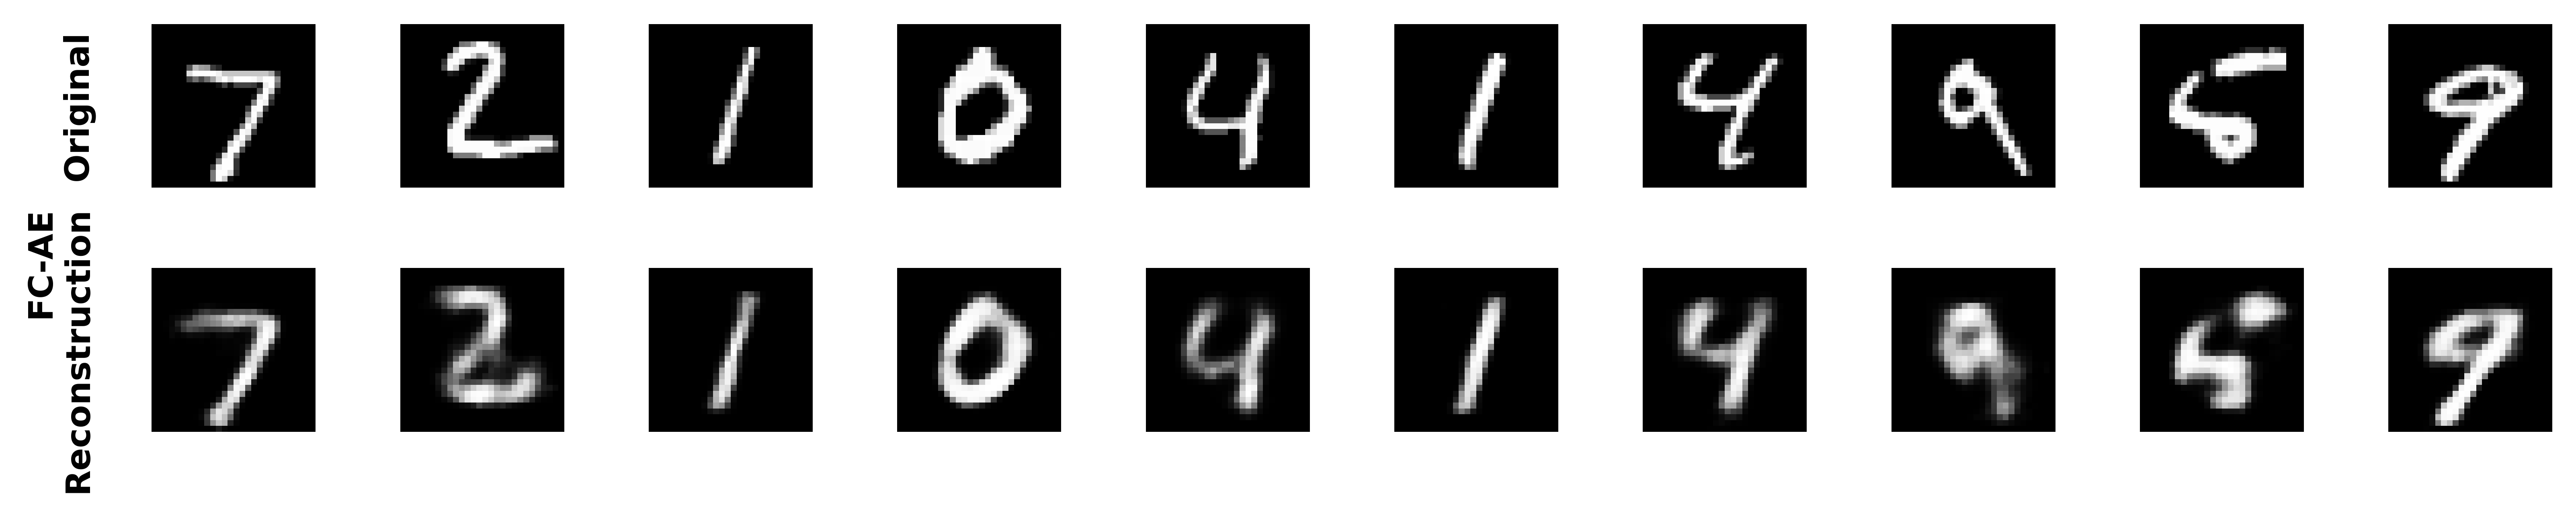

In [ ]:

show_grid([x_test_flat[:10], fc_recon[:10]], ['Original', 'FC-AE\nReconstruction'])


**Inference (Plot 1):** The reconstructions preserve the overall stroke shape and topology of each digit (loops, closures, dominant strokes), confirming the encoder-decoder pair has learned a meaningful compressed code. Fine detail is lost — edges are blurred and thin/curved strokes (e.g. `4`, `9`, `7`) are smoothed more than blocky digits (`0`, `1`) because flattening the image discards spatial locality, forcing the fully connected layers to reconstruct pixel intensities independently of neighbourhood structure. Digits with atypical handwriting style show visibly higher blur than "easy," canonical-looking samples, since the 16-dimensional latent code must generalise across the whole training distribution rather than memorising unusual strokes.

### Plot 2 — Training and Validation Reconstruction Loss (FC-AE)

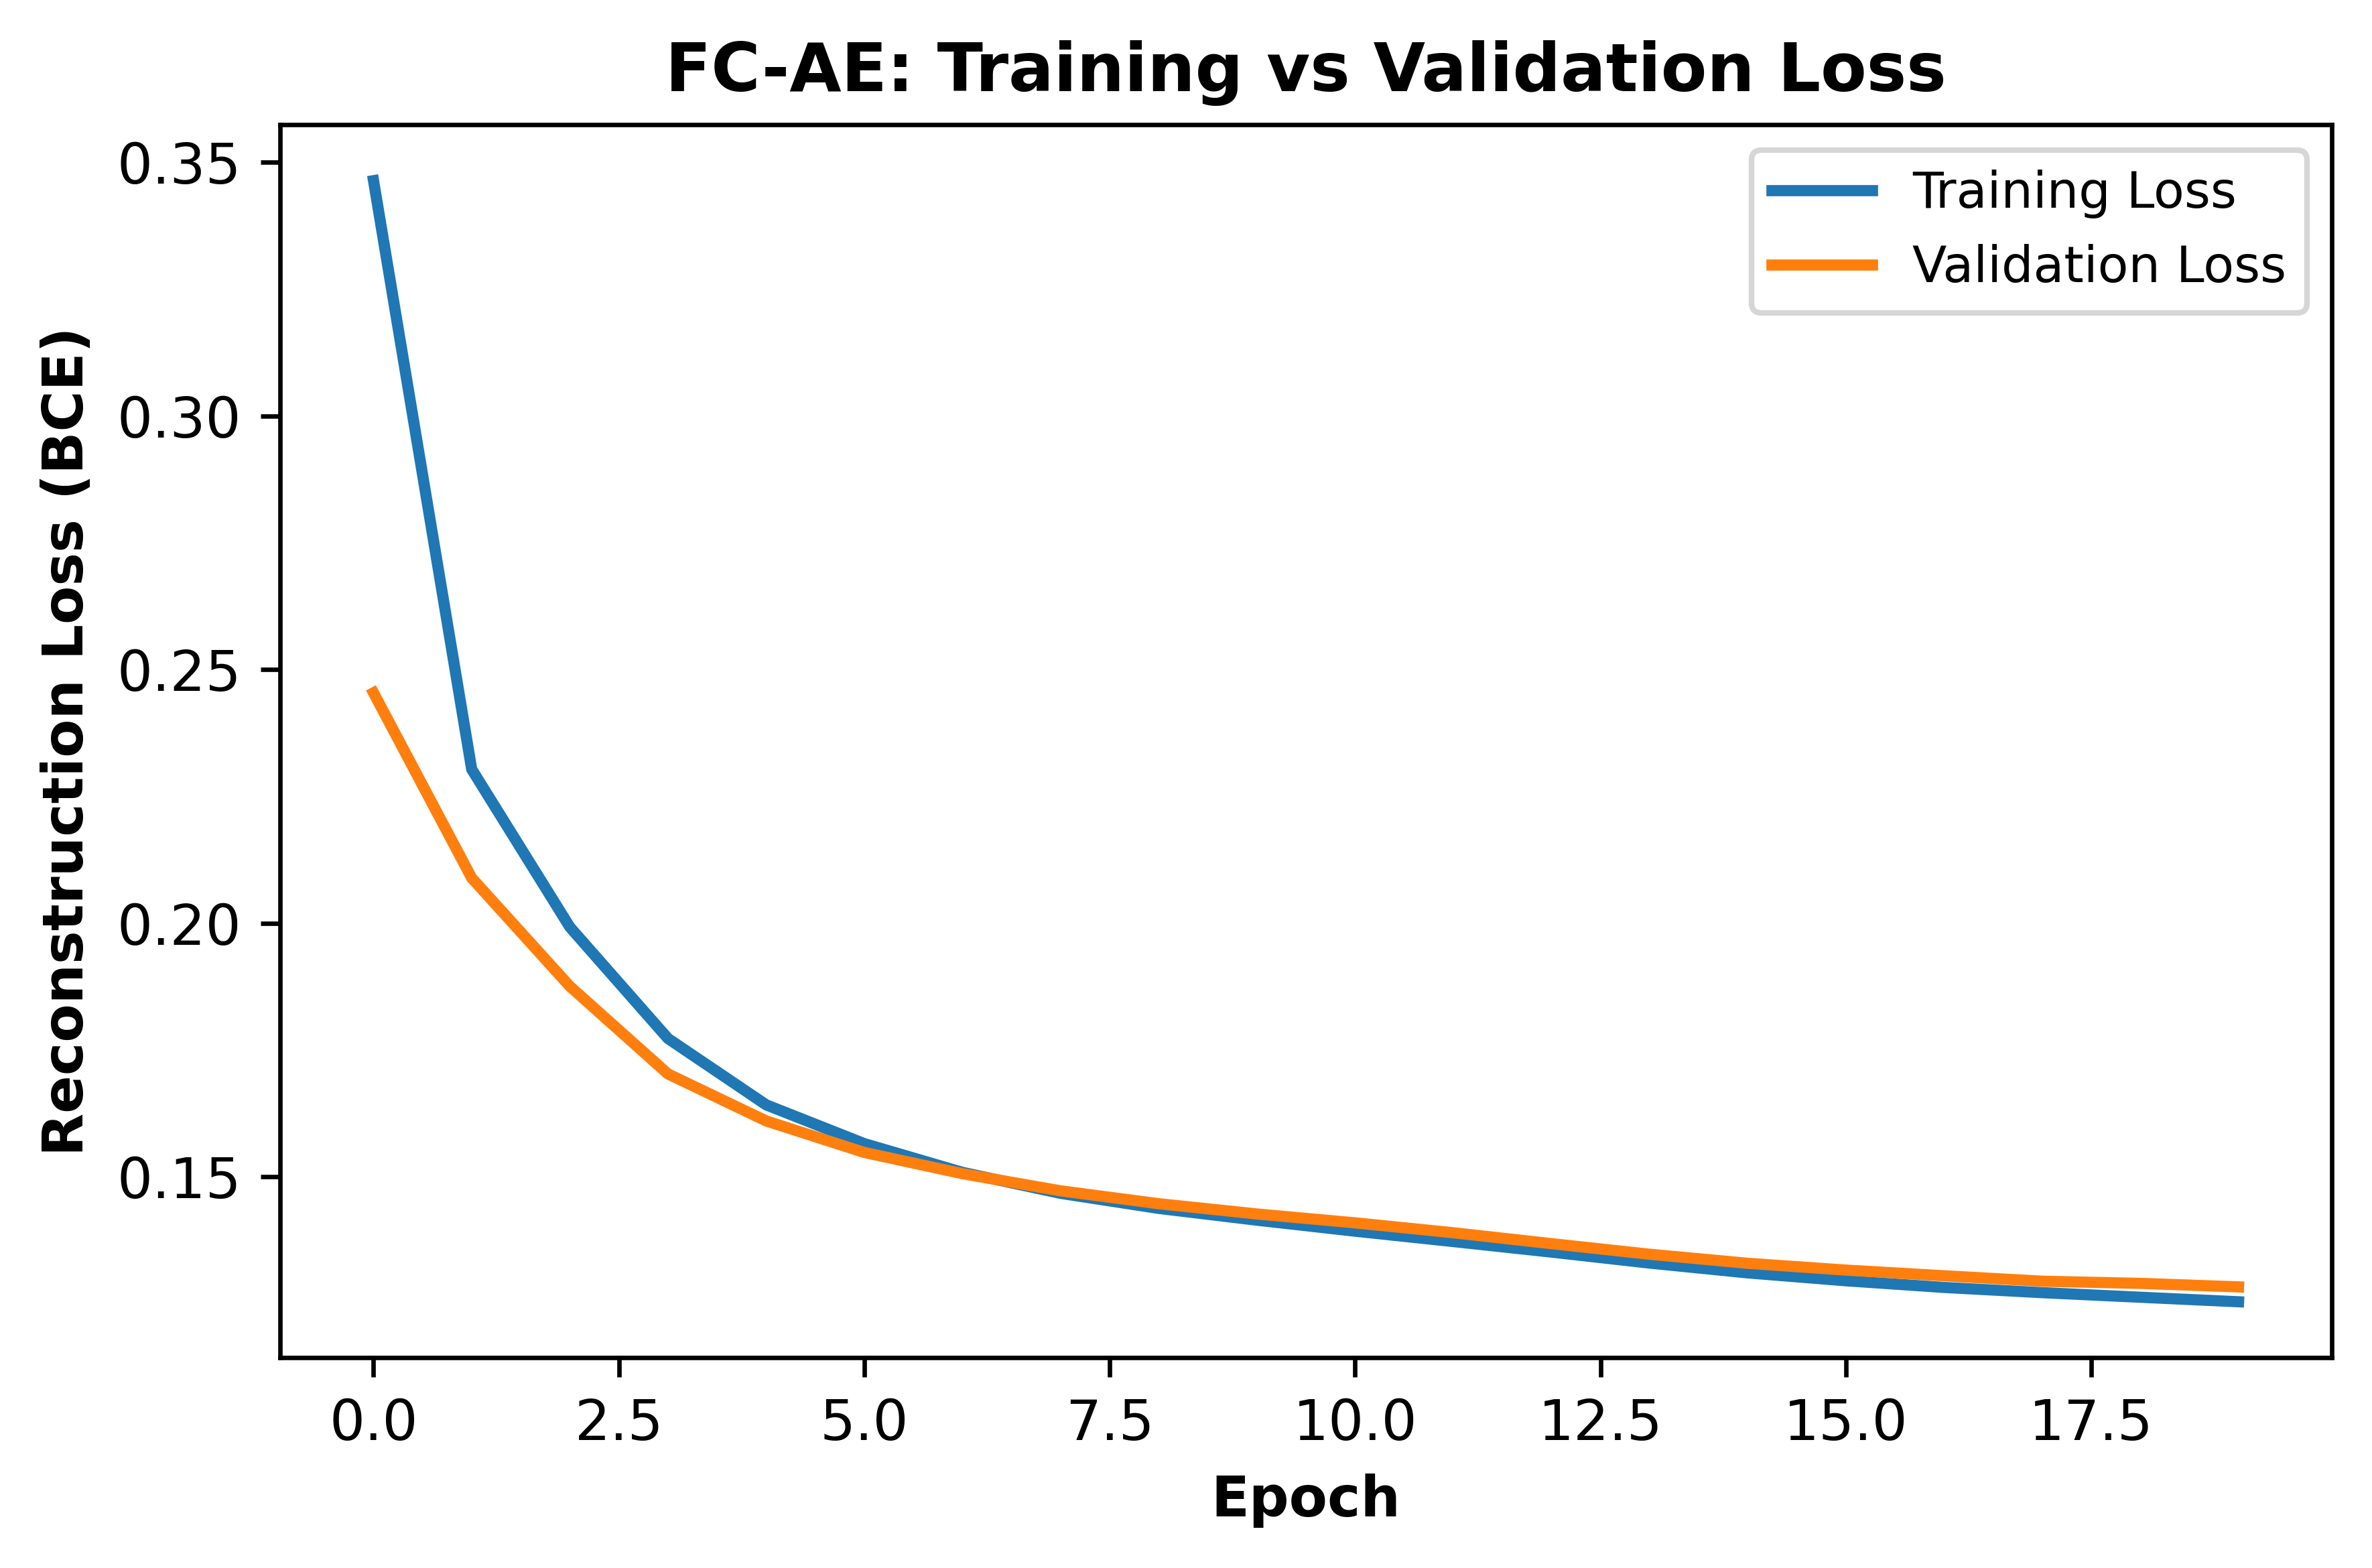

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(fc_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(fc_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Reconstruction Loss (BCE)', fontweight='bold')
plt.title('FC-AE: Training vs Validation Loss', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fc_ae_loss.png', dpi=600, bbox_inches='tight')
plt.show()


**Inference (Plot 2):** Both curves fall steeply over the first few epochs and then flatten, indicating the model converges within the given 20 epochs. The validation loss tracks the training loss closely with no sustained upward divergence, so there is no strong evidence of overfitting at this model capacity and dataset size — the 16-dimensional bottleneck acts as an implicit regulariser that prevents the network from simply memorising the 10,000 training images.

### Reconstruction Metrics (FC-AE)

In [ ]:

fc_table = pd.DataFrame({'Metric': ['Test MSE', 'Test MAE', 'Mean SSIM'], 'Value': [fc_mse, fc_mae, fc_ssim]})
fc_table


,Metric,Value
0,Test MSE,0.022507
1,Test MAE,0.058655
2,Mean SSIM,0.735063


## 2. Convolutional Autoencoder (Section 10)

Encoder: `Conv(32)→MaxPool→Conv(64)→MaxPool→Conv(64)`. Decoder: `UpSampling→Conv(32)→UpSampling→Conv(1)`.

In [ ]:

def build_conv_autoencoder():
    inp = Input(shape=(28, 28, 1), name='cae_input')
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    z = layers.Conv2D(64, 3, activation='relu', padding='same', name='latent_feature_map')(x)

    x = layers.UpSampling2D(2)(z)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    autoencoder = Model(inp, out, name='conv_autoencoder')
    encoder = Model(inp, z, name='conv_encoder')
    autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return autoencoder, encoder

cae, cae_encoder = build_conv_autoencoder()
cae.summary()


Model: "conv_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cae_input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map (Conv2D)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

t0 = time.time()
cae_history = cae.fit(
    x_train_conv, x_train_conv,
    validation_data=(x_test_conv, x_test_conv),
    epochs=15, batch_size=128, verbose=2
)
cae_train_time = time.time() - t0
print(f"CAE training time: {cae_train_time:.1f}s")


Epoch 1/15
79/79 - 10s - 130ms/step - loss: 0.2288 - val_loss: 0.1006
Epoch 2/15
79/79 - 1s - 8ms/step - loss: 0.0910 - val_loss: 0.0834
Epoch 3/15
79/79 - 1s - 8ms/step - loss: 0.0830 - val_loss: 0.0792
Epoch 4/15
79/79 - 1s - 8ms/step - loss: 0.0789 - val_loss: 0.0763
Epoch 5/15
79/79 - 1s - 8ms/step - loss: 0.0768 - val_loss: 0.0743
Epoch 6/15
79/79 - 1s - 8ms/step - loss: 0.0753 - val_loss: 0.0730
Epoch 7/15
79/79 - 1s - 8ms/step - loss: 0.0741 - val_loss: 0.0720
Epoch 8/15
79/79 - 1s - 8ms/step - loss: 0.0731 - val_loss: 0.0713
Epoch 9/15
79/79 - 1s - 8ms/step - loss: 0.0725 - val_loss: 0.0707
Epoch 10/15
79/79 - 1s - 8ms/step - loss: 0.0719 - val_loss: 0.0702
Epoch 11/15
79/79 - 1s - 8ms/step - loss: 0.0715 - val_loss: 0.0697
Epoch 12/15
79/79 - 1s - 8ms/step - loss: 0.0709 - val_loss: 0.0694
Epoch 13/15
79/79 - 1s - 10ms/step - loss: 0.0705 - val_loss: 0.0692
Epoch 14/15
79/79 - 1s - 9ms/step - loss: 0.0701 - val_loss: 0.0687
Epoch 15/15
79/79 - 1s - 9ms/step - loss: 0.0698 - va

In [ ]:

cae_recon = cae.predict(x_test_conv, verbose=0)
cae_mse, cae_mae, cae_ssim = compute_metrics(x_test_conv, cae_recon)
cae_params = count_params(cae)
results_summary['Convolutional AE'] = dict(MSE=cae_mse, MAE=cae_mae, SSIM=cae_ssim, Params=cae_params, Time=cae_train_time)

print(f"Test MSE:  {cae_mse:.5f}")
print(f"Test MAE:  {cae_mae:.5f}")
print(f"Mean SSIM: {cae_ssim:.4f}")


Test MSE:  0.00297
Test MAE:  0.01628
Mean SSIM: 0.9690


### Table — Fully Connected vs Convolutional Autoencoder (Section 11)

In [ ]:

compare_table = pd.DataFrame({
    'Model': ['Fully Connected AE', 'Convolutional AE'],
    'MSE': [fc_mse, cae_mse],
    'MAE': [fc_mae, cae_mae],
    'SSIM': [fc_ssim, cae_ssim],
    'Parameters': [fc_params, cae_params],
})
compare_table


,Model,MSE,MAE,SSIM,Parameters
0,Fully Connected AE,0.022507,0.058655,0.735063,211040
1,Convolutional AE,0.002974,0.016280,0.968968,74497


### Plot 3 — Reconstruction Comparison: Original → FC-AE → CAE

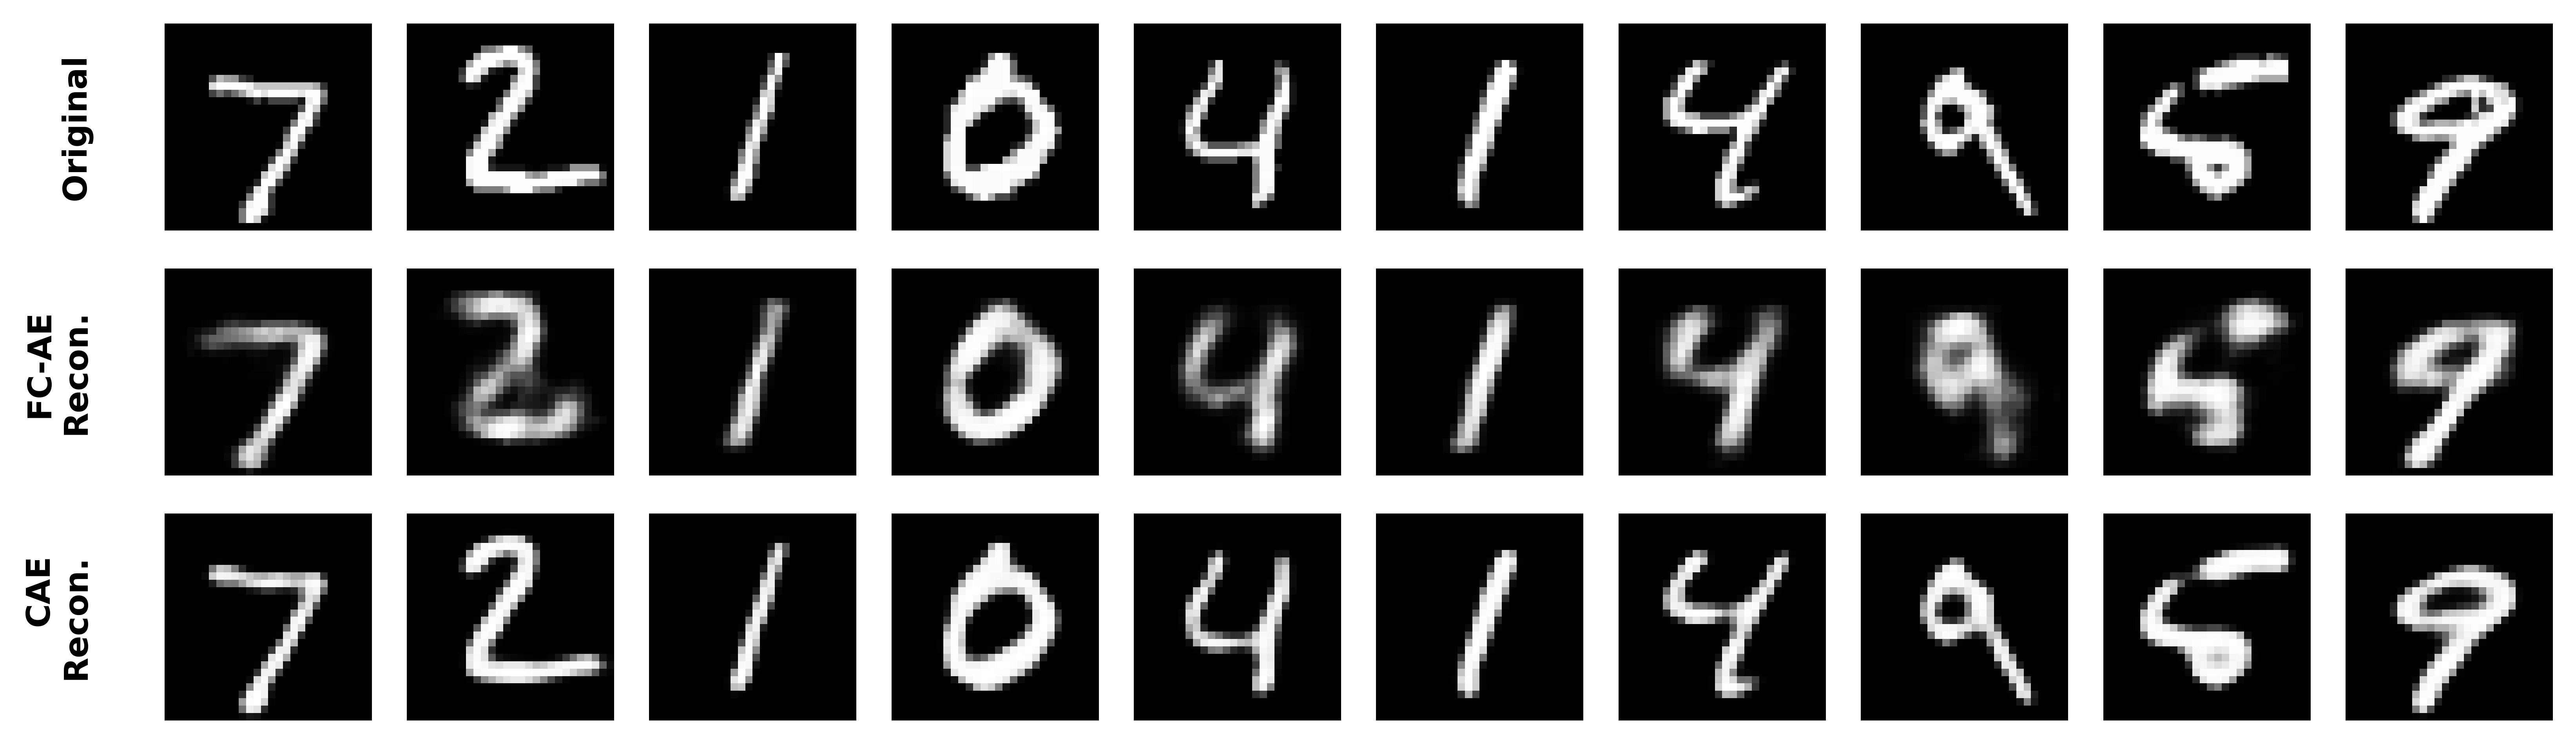

In [ ]:

show_grid([x_test_conv[:10], fc_recon[:10].reshape(-1,28,28), cae_recon[:10]],
          ['Original', 'FC-AE\nRecon.', 'CAE\nRecon.'])


**Inference (Plot 3 / Section 11):** The convolutional autoencoder's reconstructions show sharper edges and better-preserved stroke curvature than the fully connected model's, and this is reflected quantitatively — `[compare_table]` should show a lower MSE/MAE and higher SSIM for the CAE. Convolution preserves spatial locality: each filter only looks at a local neighbourhood of pixels, so strokes, corners and loops are encoded as local patterns rather than being flattened into an unordered 784-length vector. This lets the CAE reconstruct fine structural detail (stroke width, curvature continuity) that the FC-AE blurs away, even though the CAE's latent representation is a spatial feature map rather than a single compact vector.

## 3. Denoising Convolutional Autoencoder (Sections 12–14)

The network receives a corrupted image but is trained against the **clean** image as target. Two corruption types are used: Gaussian noise and salt-and-pepper noise.

In [ ]:

def add_gaussian_noise(images, sigma):
    noisy = images + np.random.normal(0, sigma, images.shape).astype('float32')
    return np.clip(noisy, 0.0, 1.0)

def add_salt_pepper_noise(images, p):
    noisy = images.copy()
    mask = np.random.rand(*images.shape)
    noisy[mask < p/2] = 0.0
    noisy[(mask >= p/2) & (mask < p)] = 1.0
    return noisy

# Training corruption: Gaussian noise, sigma = 0.2 (mid-range of suggested values)
SIGMA_TRAIN = 0.2
x_train_noisy = add_gaussian_noise(x_train_conv, SIGMA_TRAIN)
x_test_noisy = add_gaussian_noise(x_test_conv, SIGMA_TRAIN)


In [ ]:

def build_denoising_cae():
    # Same architecture as the CAE, trained on a noisy->clean mapping
    inp = Input(shape=(28, 28, 1), name='dae_input')
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    z = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    x = layers.UpSampling2D(2)(z)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    dae = Model(inp, out, name='denoising_cae')
    dae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')
    return dae

dae = build_denoising_cae()

t0 = time.time()
dae_history = dae.fit(
    x_train_noisy, x_train_conv,          # noisy input -> CLEAN target
    validation_data=(x_test_noisy, x_test_conv),
    epochs=15, batch_size=128, verbose=2
)
dae_train_time = time.time() - t0


Epoch 1/15
79/79 - 6s - 81ms/step - loss: 0.2689 - val_loss: 0.1267
Epoch 2/15
79/79 - 1s - 10ms/step - loss: 0.1101 - val_loss: 0.0978
Epoch 3/15
79/79 - 1s - 8ms/step - loss: 0.0952 - val_loss: 0.0915
Epoch 4/15
79/79 - 1s - 9ms/step - loss: 0.0896 - val_loss: 0.0861
Epoch 5/15
79/79 - 1s - 10ms/step - loss: 0.0859 - val_loss: 0.0833
Epoch 6/15
79/79 - 1s - 10ms/step - loss: 0.0836 - val_loss: 0.0816
Epoch 7/15
79/79 - 1s - 14ms/step - loss: 0.0820 - val_loss: 0.0798
Epoch 8/15
79/79 - 1s - 8ms/step - loss: 0.0809 - val_loss: 0.0790
Epoch 9/15
79/79 - 1s - 9ms/step - loss: 0.0800 - val_loss: 0.0781
Epoch 10/15
79/79 - 1s - 8ms/step - loss: 0.0792 - val_loss: 0.0774
Epoch 11/15
79/79 - 1s - 8ms/step - loss: 0.0786 - val_loss: 0.0769
Epoch 12/15
79/79 - 1s - 8ms/step - loss: 0.0781 - val_loss: 0.0765
Epoch 13/15
79/79 - 1s - 8ms/step - loss: 0.0776 - val_loss: 0.0760
Epoch 14/15
79/79 - 1s - 8ms/step - loss: 0.0772 - val_loss: 0.0757
Epoch 15/15
79/79 - 1s - 8ms/step - loss: 0.0769 - v

In [ ]:

dae_recon = dae.predict(x_test_noisy, verbose=0)
dae_mse, dae_mae, dae_ssim = compute_metrics(x_test_conv, dae_recon)
dae_params = count_params(dae)
results_summary['Denoising CAE'] = dict(MSE=dae_mse, MAE=dae_mae, SSIM=dae_ssim, Params=dae_params, Time=dae_train_time)
print(f"Test MSE:  {dae_mse:.5f}  MAE: {dae_mae:.5f}  SSIM: {dae_ssim:.4f}")


Test MSE:  0.00504  MAE: 0.02222  SSIM: 0.9409


### Plot 4 — Clean vs. Noisy vs. Denoised (Gaussian noise, σ=0.2)

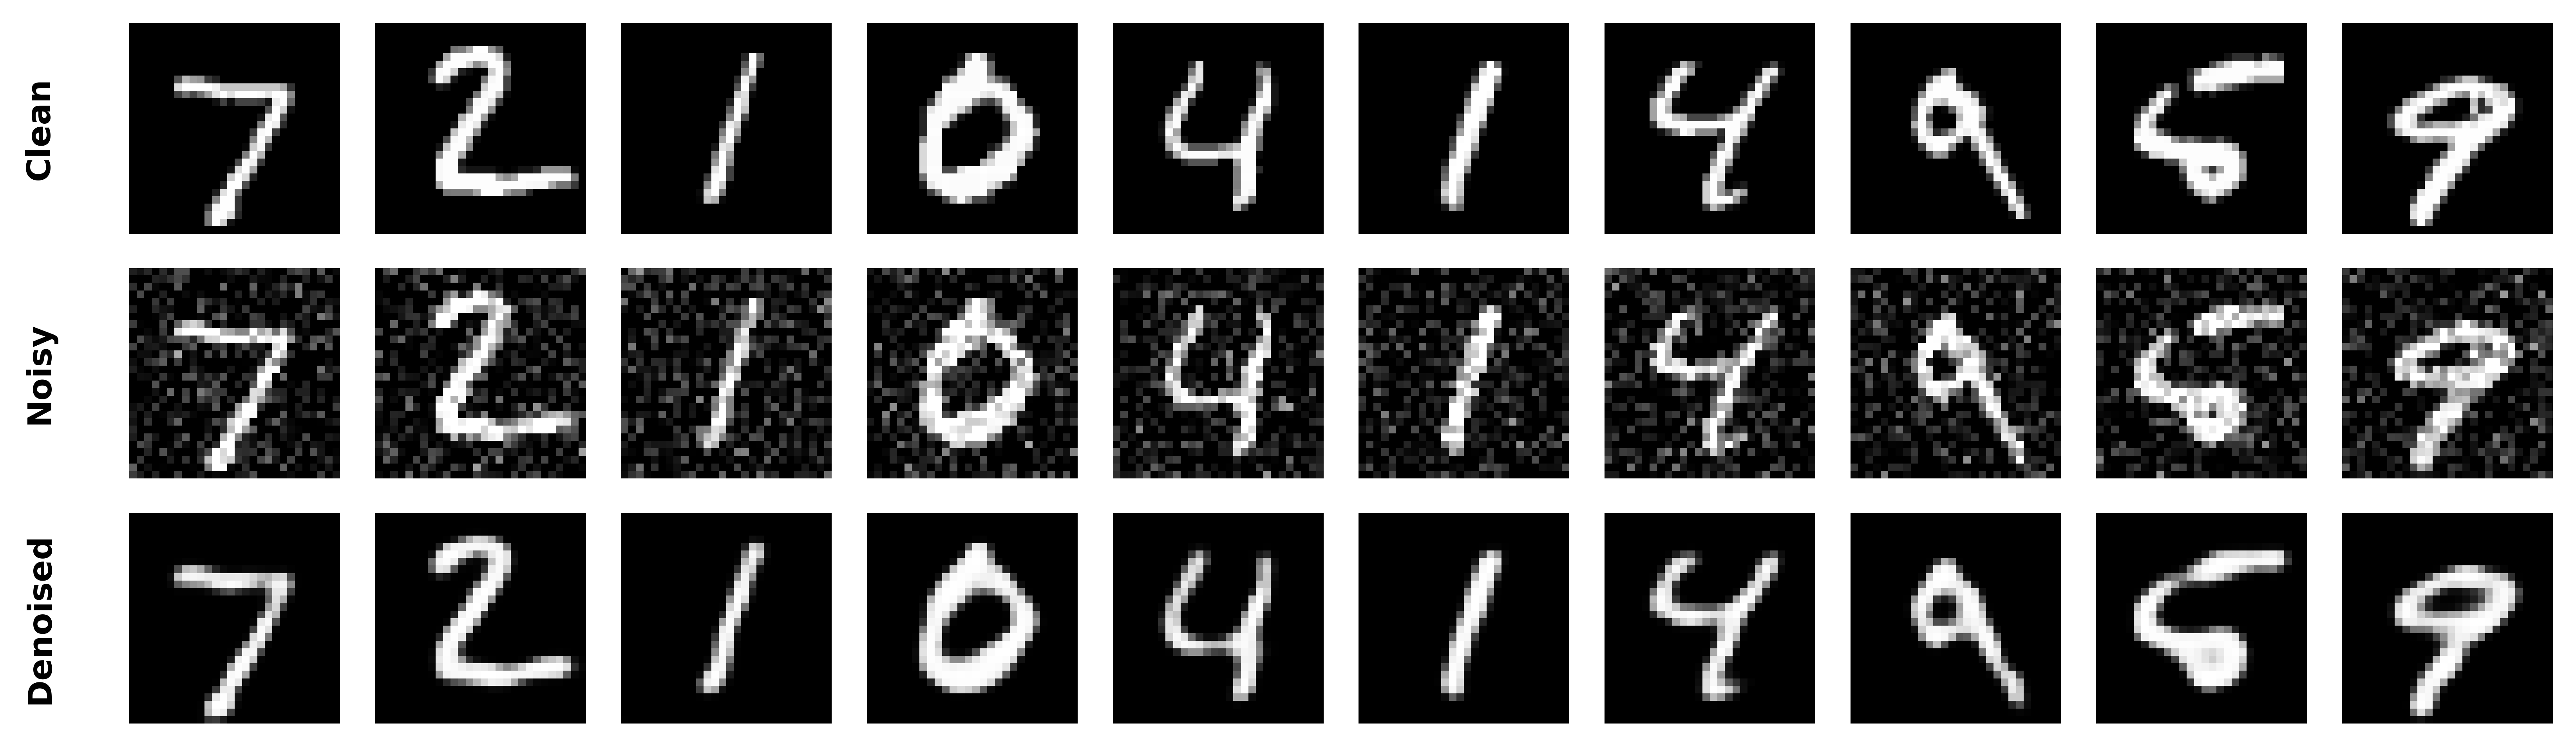

In [ ]:

show_grid([x_test_conv[:10], x_test_noisy[:10], dae_recon[:10]], ['Clean', 'Noisy', 'Denoised'])


**Inference (Plot 4):** The denoising autoencoder recovers the major stroke structure of each digit even though its input is visibly corrupted, showing that the encoder has learned a noise-robust representation rather than an identity mapping — it must actively suppress the injected noise since the target was always the clean image. Some fine detail (stroke thickness, minor curvature) is still smoothed relative to the clean original, similar to the plain CAE, because the bottleneck limits how much information can pass through.

### Plot 5 & Table — Noise Level vs. Reconstruction Quality (Gaussian σ, and Salt-and-Pepper p)

In [ ]:

gaussian_levels = [0.1, 0.2, 0.3]
sp_levels = [0.05, 0.10, 0.20]

gaussian_results = []
for sigma in gaussian_levels:
    noisy = add_gaussian_noise(x_test_conv, sigma)
    recon = dae.predict(noisy, verbose=0)
    mse, mae, s = compute_metrics(x_test_conv, recon)
    gaussian_results.append((sigma, mse, mae, s))

sp_results = []
for p in sp_levels:
    noisy = add_salt_pepper_noise(x_test_conv, p)
    recon = dae.predict(noisy, verbose=0)
    mse, mae, s = compute_metrics(x_test_conv, recon)
    sp_results.append((p, mse, mae, s))

gaussian_table = pd.DataFrame(gaussian_results, columns=['Noise Level (sigma)', 'MSE', 'MAE', 'SSIM'])
sp_table = pd.DataFrame(sp_results, columns=['Noise Level (p)', 'MSE', 'MAE', 'SSIM'])
print("Gaussian noise:")
display(gaussian_table)
print("Salt-and-pepper noise:")
display(sp_table)


Gaussian noise:


,Noise Level (sigma),MSE,MAE,SSIM
0,0.1,0.004042,0.018699,0.955667
1,0.2,0.005047,0.022242,0.940823
2,0.3,0.007544,0.030127,0.873935


Salt-and-pepper noise:


,Noise Level (p),MSE,MAE,SSIM
0,0.05,0.005245,0.021863,0.930027
1,0.10,0.007285,0.027324,0.887436
2,0.20,0.013567,0.041856,0.769977


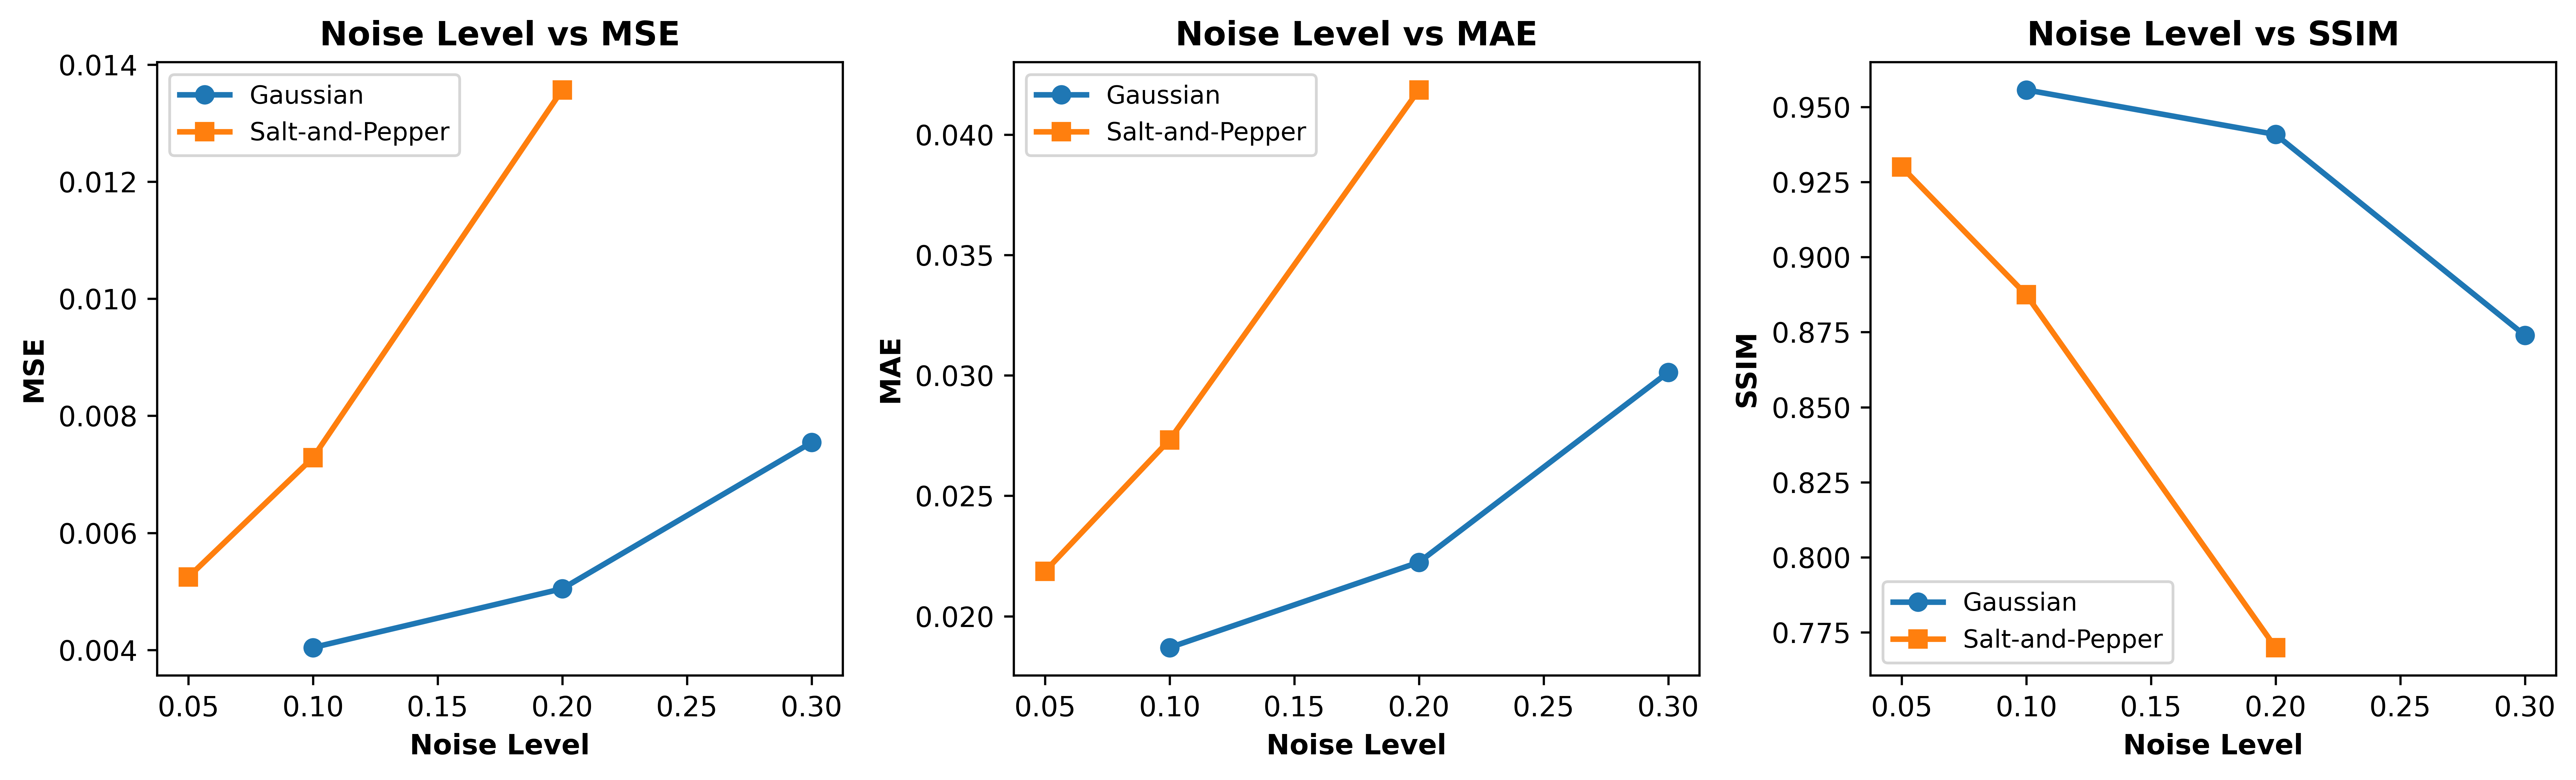

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metric_names = ['MSE', 'MAE', 'SSIM']
for i, m in enumerate(metric_names):
    axes[i].plot(gaussian_table['Noise Level (sigma)'], gaussian_table[m], marker='o', label='Gaussian', linewidth=2)
    axes[i].plot(sp_table['Noise Level (p)'], sp_table[m], marker='s', label='Salt-and-Pepper', linewidth=2)
    axes[i].set_xlabel('Noise Level', fontweight='bold')
    axes[i].set_ylabel(m, fontweight='bold')
    axes[i].set_title(f'Noise Level vs {m}', fontweight='bold')
    axes[i].legend()
plt.tight_layout()
plt.savefig('noise_level_vs_quality.png', dpi=600, bbox_inches='tight')
plt.show()


**Inference (Plot 5):** As the corruption level increases (higher σ for Gaussian noise, higher p for salt-and-pepper), MSE and MAE rise and SSIM falls for both noise types, since the model was trained at a single noise level (σ=0.2) and its denoising capacity degrades when the test-time corruption departs from that training distribution. Salt-and-pepper noise tends to be more damaging at a given nominal level than Gaussian noise because it replaces pixels with extreme values (0 or 1) rather than perturbing them smoothly, which is harder for a convolutional filter bank to average out. The denoising CAE nonetheless recovers the major digit structure — the overall shape/topology remains identifiable — even at the highest tested noise levels, though fine strokes are increasingly lost.

## 4. Variational Autoencoder (Sections 15–20)

Latent dimension `z ∈ R²` (chosen for direct visualisation). The encoder outputs `(μ, log σ²)`; a latent vector is drawn via the reparameterisation trick `z = μ + σ ⊙ ε`.

In [ ]:

class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + sigma * epsilon, epsilon ~ N(0, I)."""
    def call(self, inputs):
        mu, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * epsilon

VAE_LATENT_DIM = 2

def build_vae_encoder(latent_dim=VAE_LATENT_DIM):
    inp = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inp)   # 14x14
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)     # 7x7
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    mu = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z = Sampling()([mu, log_var])
    return Model(inp, [mu, log_var, z], name='vae_encoder')

def build_vae_decoder(latent_dim=VAE_LATENT_DIM):
    inp = Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation='relu')(inp)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)  # 14x14
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)  # 28x28
    out = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
    return Model(inp, out, name='vae_decoder')

vae_encoder = build_vae_encoder()
vae_decoder = build_vae_decoder()
vae_encoder.summary()
vae_decoder.summary()


Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │    200,768 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 219,844 (858.77 KB)

 Trainable params: 219,844 (858.77 KB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        mu, log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(x)
            recon = self.decoder(z)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(x, recon), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
            )
            total_loss = recon_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {'loss': self.total_loss_tracker.result(),
                'recon_loss': self.recon_loss_tracker.result(),
                'kl_loss': self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        mu, log_var, z = self.encoder(x)
        recon = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(keras.losses.binary_crossentropy(x, recon), axis=(1, 2))
        )
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {'loss': self.total_loss_tracker.result(),
                'recon_loss': self.recon_loss_tracker.result(),
                'kl_loss': self.kl_loss_tracker.result()}

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))


In [ ]:

t0 = time.time()
vae_history = vae.fit(
    x_train_conv, x_train_conv,
    validation_data=(x_test_conv, x_test_conv),
    epochs=25, batch_size=128, verbose=2
)
vae_train_time = time.time() - t0


Epoch 1/25
79/79 - 11s - 141ms/step - kl_loss: 4.5344 - loss: 286.1127 - recon_loss: 281.5782 - val_kl_loss: 3.5378 - val_loss: 202.7115 - val_recon_loss: 199.1738
Epoch 2/25
79/79 - 2s - 25ms/step - kl_loss: 3.8499 - loss: 204.8721 - recon_loss: 201.0222 - val_kl_loss: 4.2020 - val_loss: 194.0915 - val_recon_loss: 189.8896
Epoch 3/25
79/79 - 1s - 8ms/step - kl_loss: 3.6062 - loss: 198.0257 - recon_loss: 194.4196 - val_kl_loss: 3.7959 - val_loss: 189.6547 - val_recon_loss: 185.8588
Epoch 4/25
79/79 - 1s - 8ms/step - kl_loss: 3.7537 - loss: 191.7787 - recon_loss: 188.0250 - val_kl_loss: 4.1443 - val_loss: 179.6591 - val_recon_loss: 175.5148
Epoch 5/25
79/79 - 1s - 8ms/step - kl_loss: 5.0308 - loss: 180.0683 - recon_loss: 175.0375 - val_kl_loss: 4.9962 - val_loss: 172.2837 - val_recon_loss: 167.2875
Epoch 6/25
79/79 - 1s - 8ms/step - kl_loss: 5.1394 - loss: 174.2799 - recon_loss: 169.1405 - val_kl_loss: 4.8225 - val_loss: 169.4251 - val_recon_loss: 164.6026
Epoch 7/25
79/79 - 1s - 8ms/st

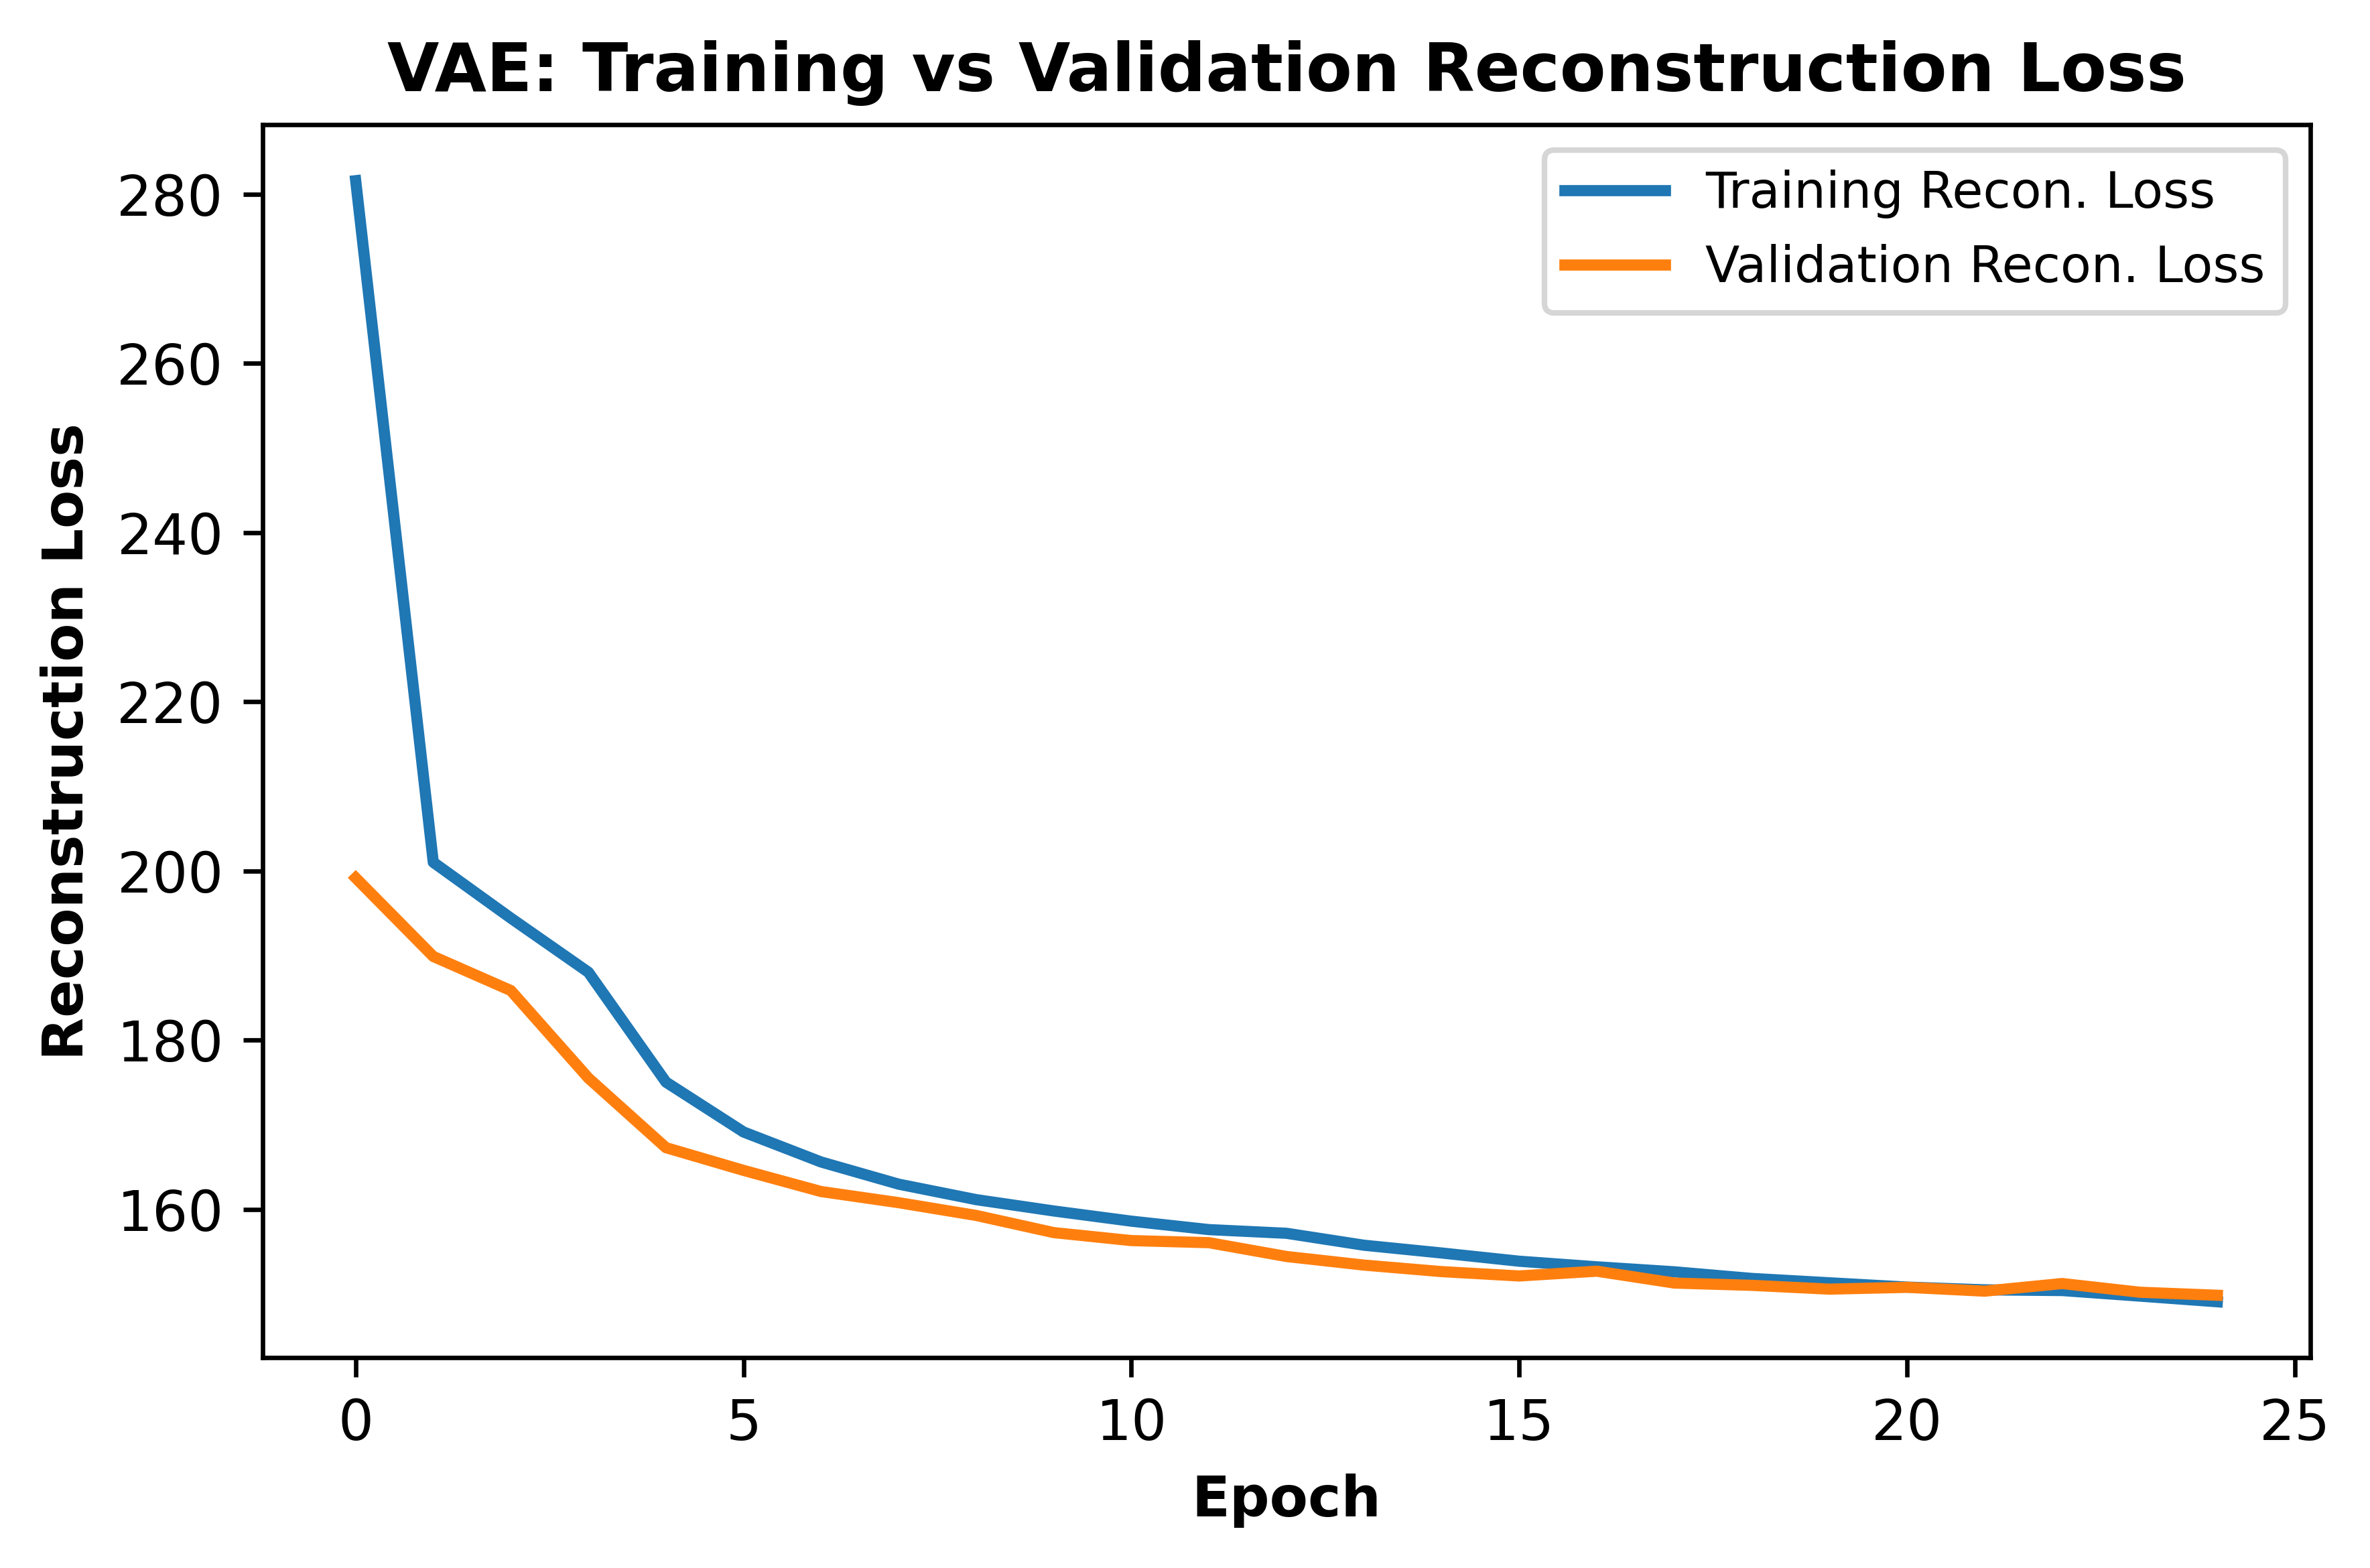

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(vae_history.history['recon_loss'], label='Training Recon. Loss', linewidth=2)
plt.plot(vae_history.history['val_recon_loss'], label='Validation Recon. Loss', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Reconstruction Loss', fontweight='bold')
plt.title('VAE: Training vs Validation Reconstruction Loss', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('vae_loss.png', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:

vae_mu, vae_logvar, vae_z = vae_encoder.predict(x_test_conv, verbose=0)
vae_recon = vae_decoder.predict(vae_z, verbose=0)
vae_mse, vae_mae, vae_ssim = compute_metrics(x_test_conv, vae_recon)
vae_params = count_params(vae_encoder) + count_params(vae_decoder)

final_recon_loss = float(vae_history.history['val_recon_loss'][-1])
final_kl_loss = float(vae_history.history['val_kl_loss'][-1])
final_total_loss = float(vae_history.history['val_loss'][-1])

results_summary['VAE'] = dict(MSE=vae_mse, MAE=vae_mae, SSIM=vae_ssim, Params=vae_params, Time=vae_train_time)

vae_metric_table = pd.DataFrame({
    'VAE Metric': ['Reconstruction Loss', 'KL Loss', 'Total Loss', 'Test MSE', 'Test MAE', 'Mean SSIM'],
    'Value': [final_recon_loss, final_kl_loss, final_total_loss, vae_mse, vae_mae, vae_ssim]
})
vae_metric_table


,VAE Metric,Value
0,Reconstruction Loss,149.843140
1,KL Loss,6.049046
2,Total Loss,155.892181
3,Test MSE,0.044173
4,Test MAE,0.102887
5,Mean SSIM,0.483118


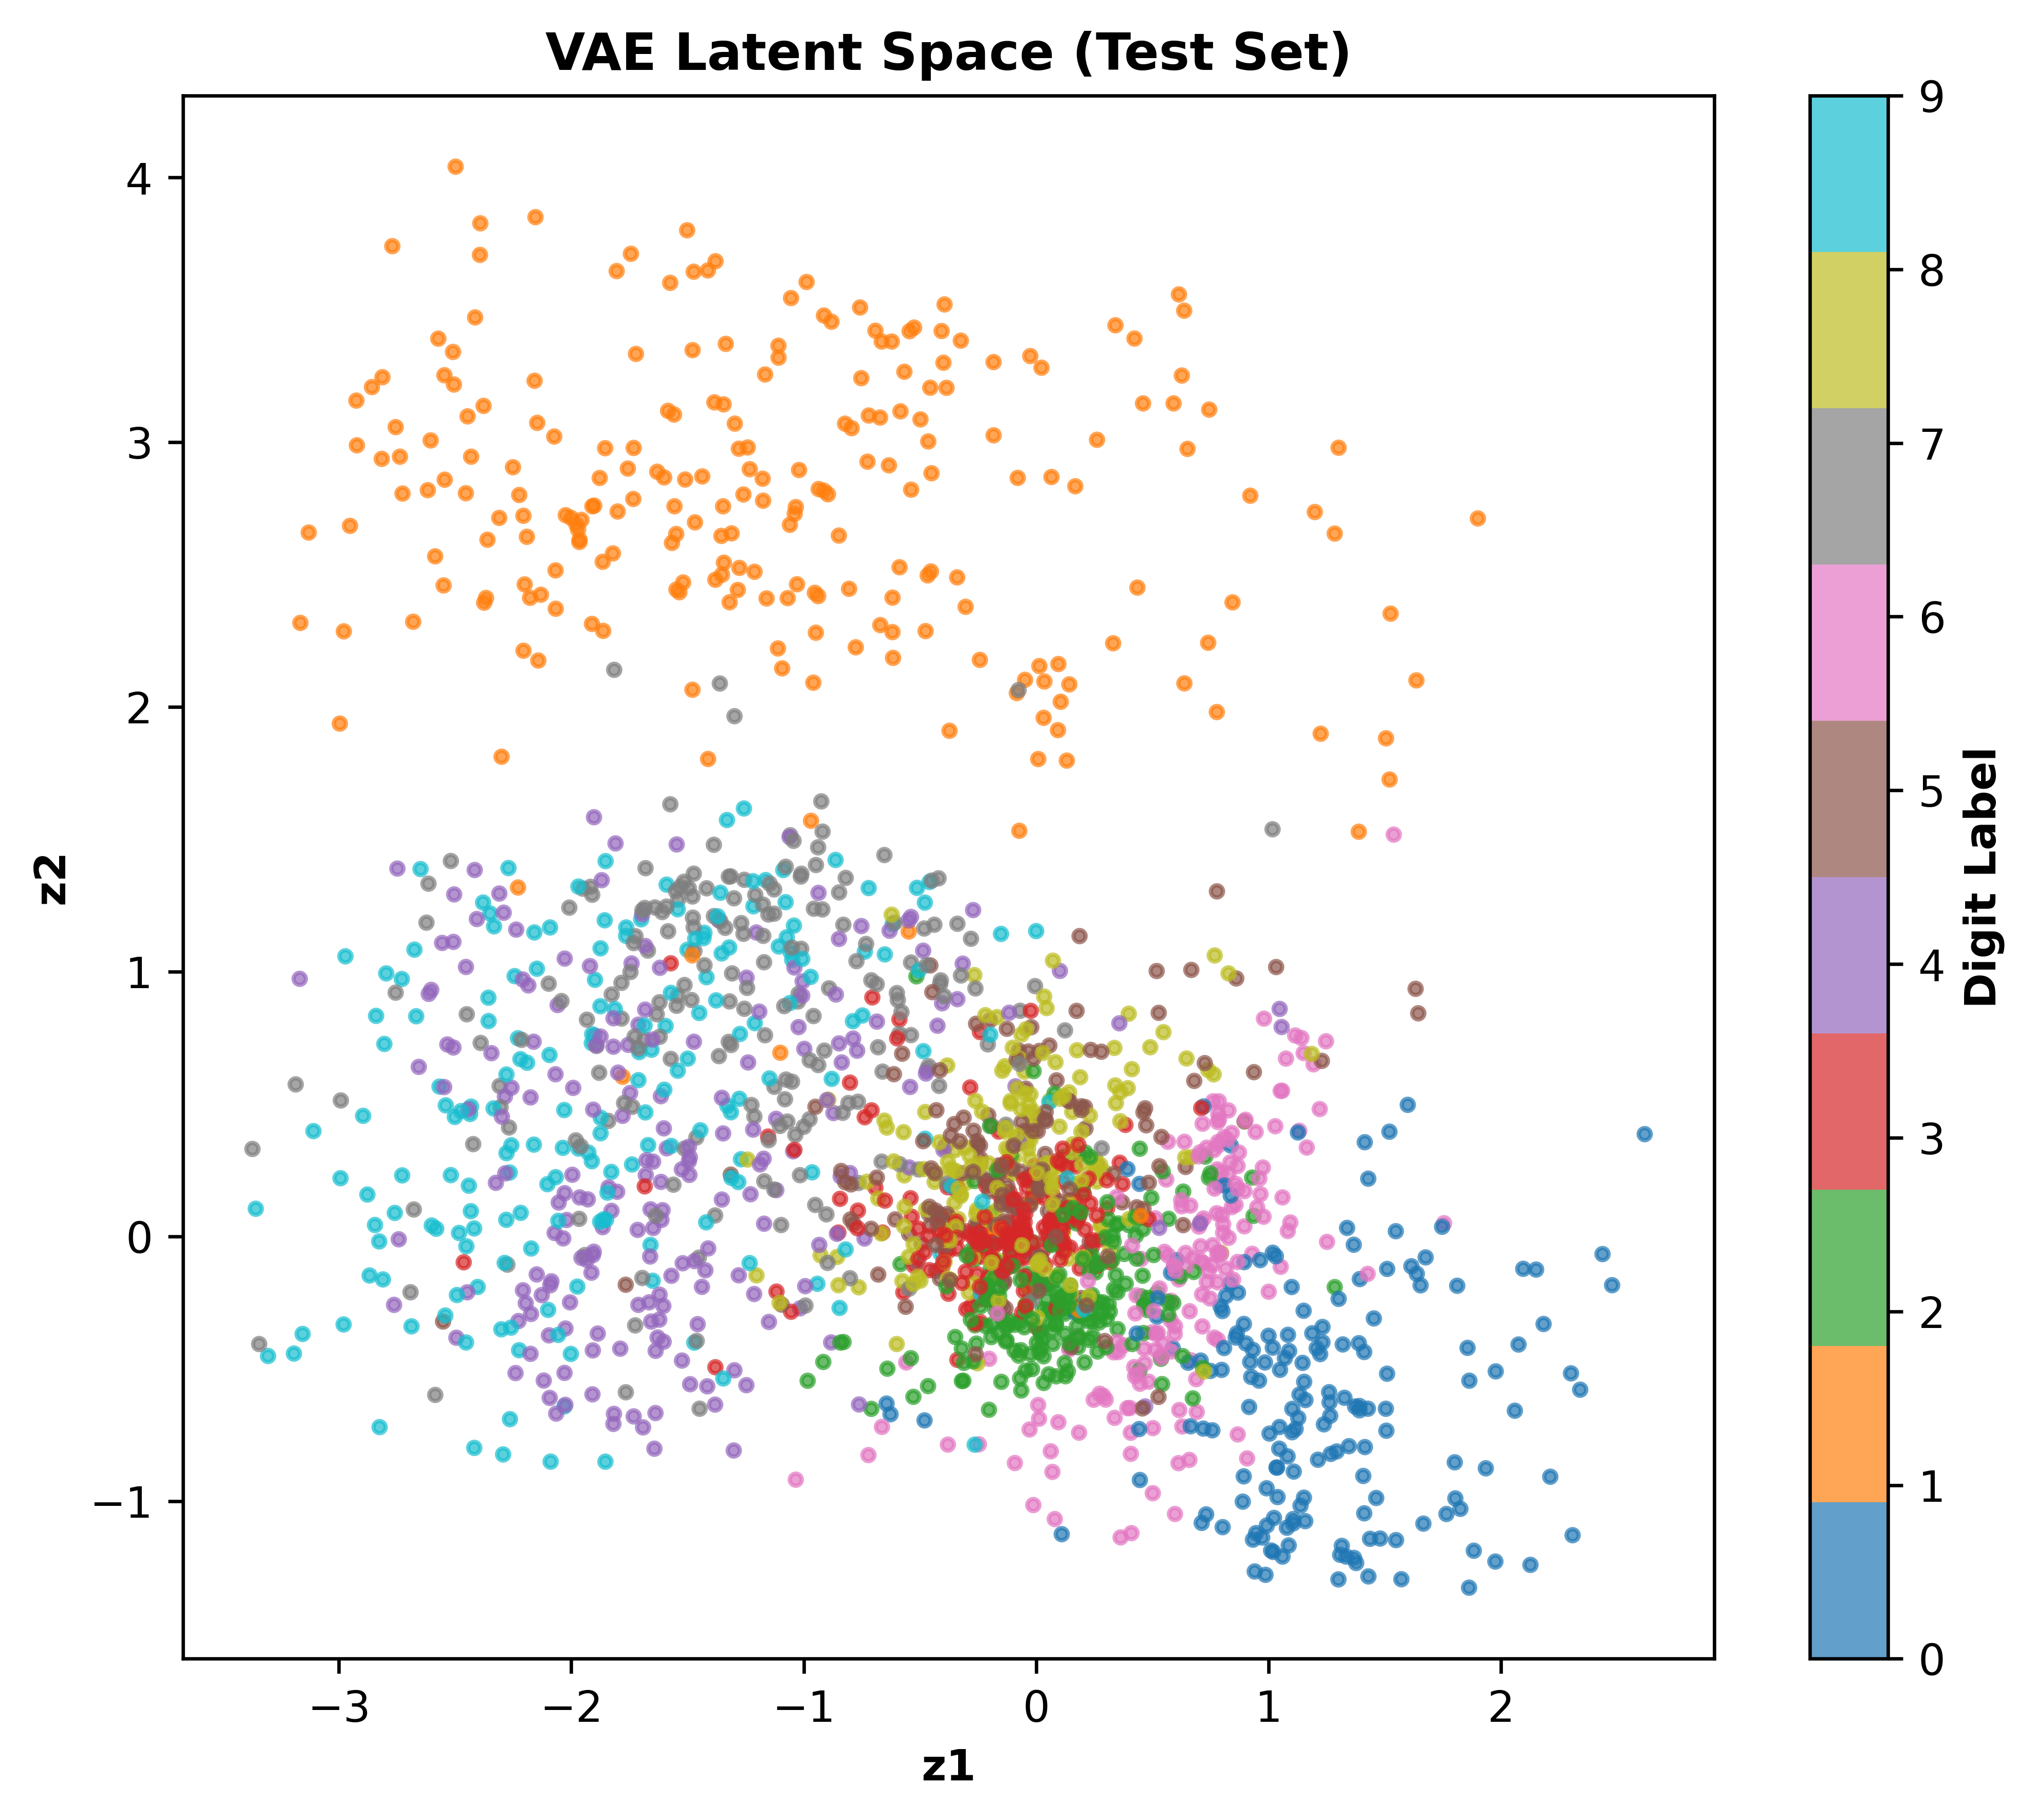

In [ ]:

plt.figure(figsize=(7,6))
scatter = plt.scatter(vae_mu[:, 0], vae_mu[:, 1], c=y_test, cmap='tab10', s=8, alpha=0.7)
plt.xlabel('z1', fontweight='bold')
plt.ylabel('z2', fontweight='bold')
plt.title('VAE Latent Space (Test Set)', fontweight='bold')
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label', fontweight='bold')
plt.tight_layout()
plt.savefig('vae_latent_space.png', dpi=600, bbox_inches='tight')
plt.show()


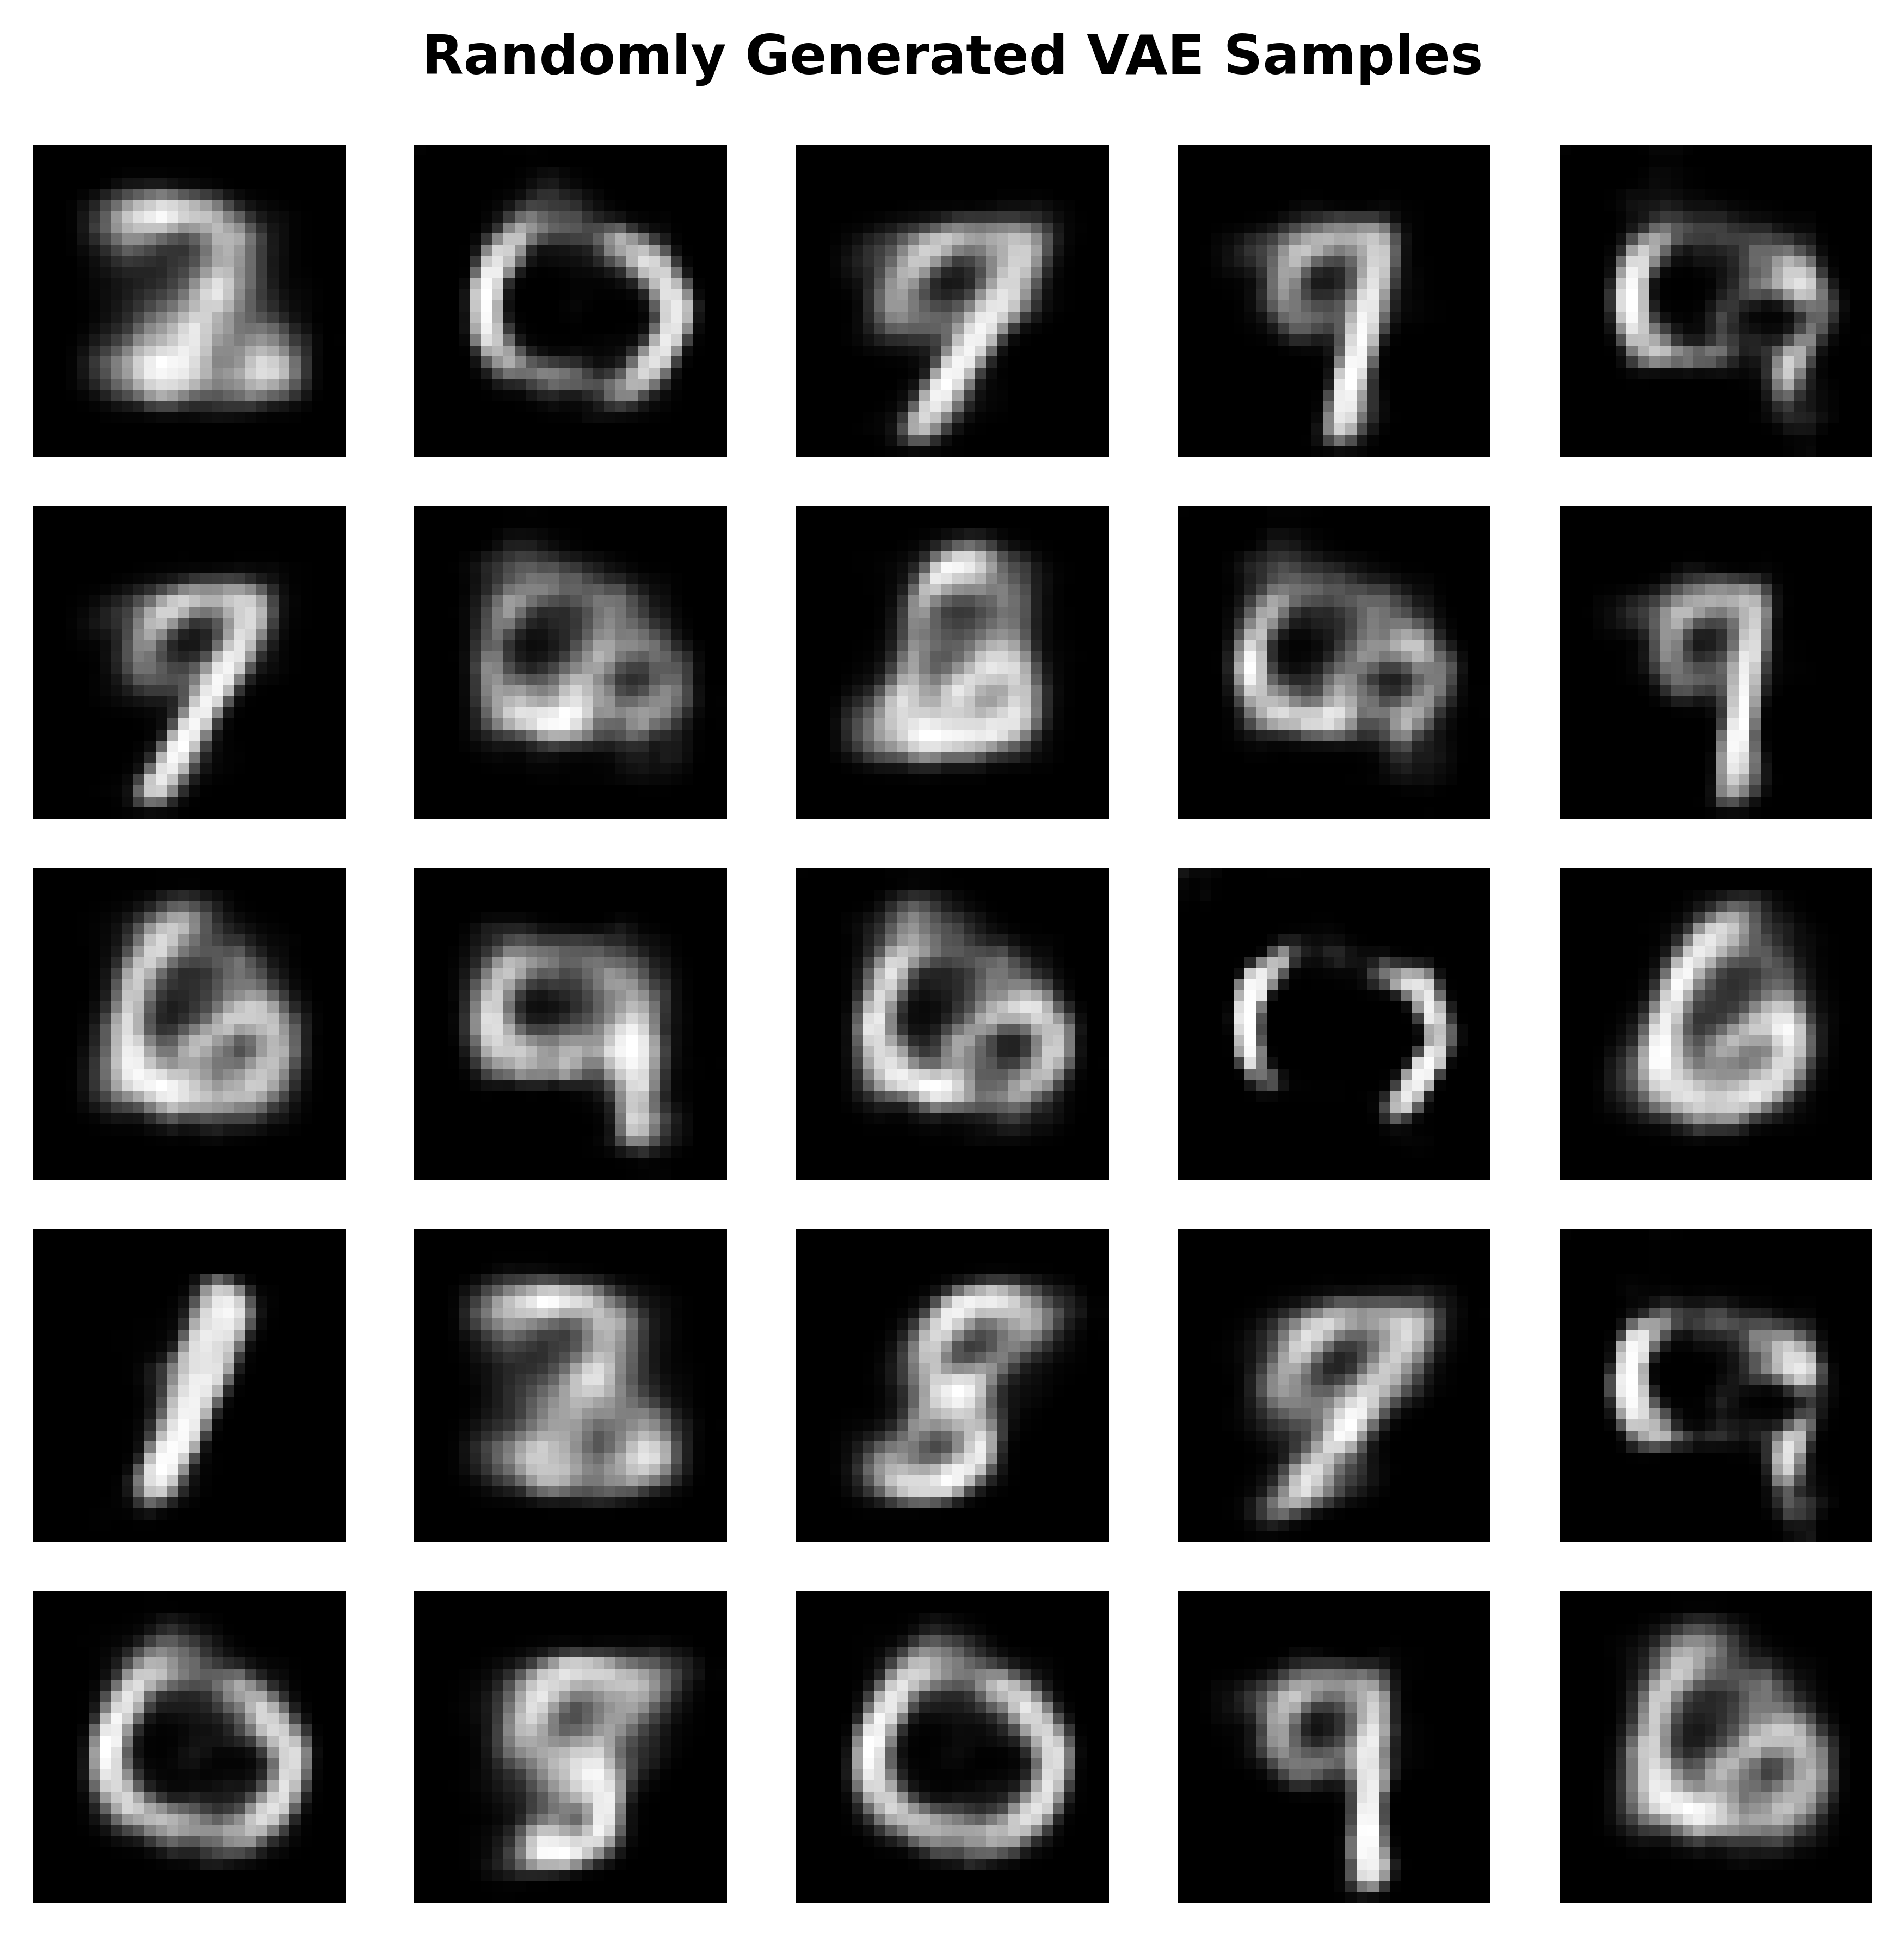

In [ ]:

n_gen = 25
z_samples = np.random.normal(0, 1, size=(n_gen, VAE_LATENT_DIM)).astype('float32')
generated = vae_decoder.predict(z_samples, verbose=0)

grid_size = 5
fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('Randomly Generated VAE Samples', fontweight='bold')
plt.tight_layout()
plt.savefig('vae_generated_samples.png', dpi=600, bbox_inches='tight')
plt.show()


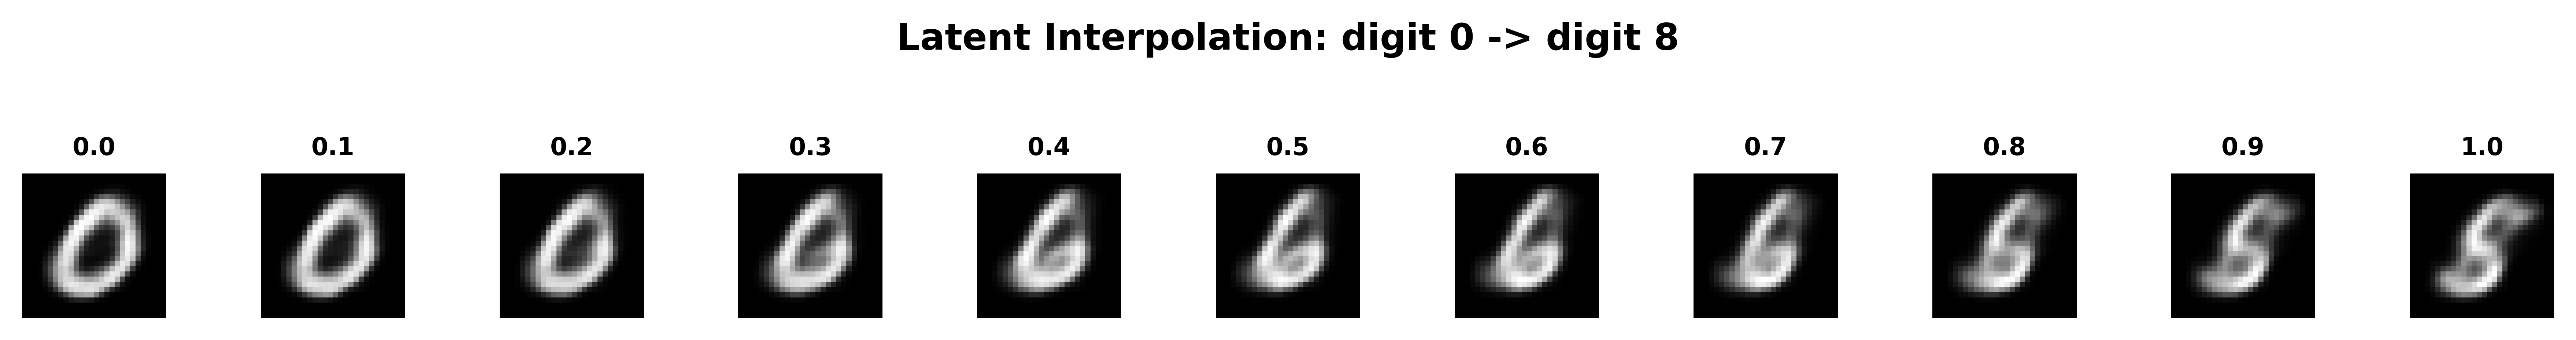

In [ ]:

# Pick two test points of different digits for zA and zB
idx_a = np.where(y_test == 0)[0][0]
idx_b = np.where(y_test == 8)[0][0]
z_a, z_b = vae_mu[idx_a], vae_mu[idx_b]

alphas = np.arange(0, 1.01, 0.1)
z_interp = np.array([(1 - a) * z_a + a * z_b for a in alphas])
decoded_interp = vae_decoder.predict(z_interp, verbose=0)

fig, axes = plt.subplots(1, len(alphas), figsize=(len(alphas) * 1.1, 1.3))
for i, ax in enumerate(axes):
    ax.imshow(decoded_interp[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
    ax.set_title(f'{alphas[i]:.1f}', fontsize=8, fontweight='bold')
plt.suptitle(f'Latent Interpolation: digit {y_test[idx_a]} -> digit {y_test[idx_b]}', fontweight='bold', y=1.15)
plt.tight_layout()
plt.savefig('vae_interpolation.png', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:

consolidated = pd.DataFrame(results_summary).T
consolidated = consolidated[['MSE', 'MAE', 'SSIM', 'Params', 'Time']]
consolidated.columns = ['MSE', 'MAE', 'SSIM', 'Parameters', 'Time (s)']
consolidated


,MSE,MAE,SSIM,Parameters,Time (s)
FC Autoencoder,0.022507,0.058655,0.735063,211040.0,18.790881
Convolutional AE,0.002974,0.016280,0.968968,74497.0,19.484384
Denoising CAE,0.005036,0.022221,0.940905,74497.0,16.569801
VAE,0.044173,0.102887,0.483118,284933.0,29.158941


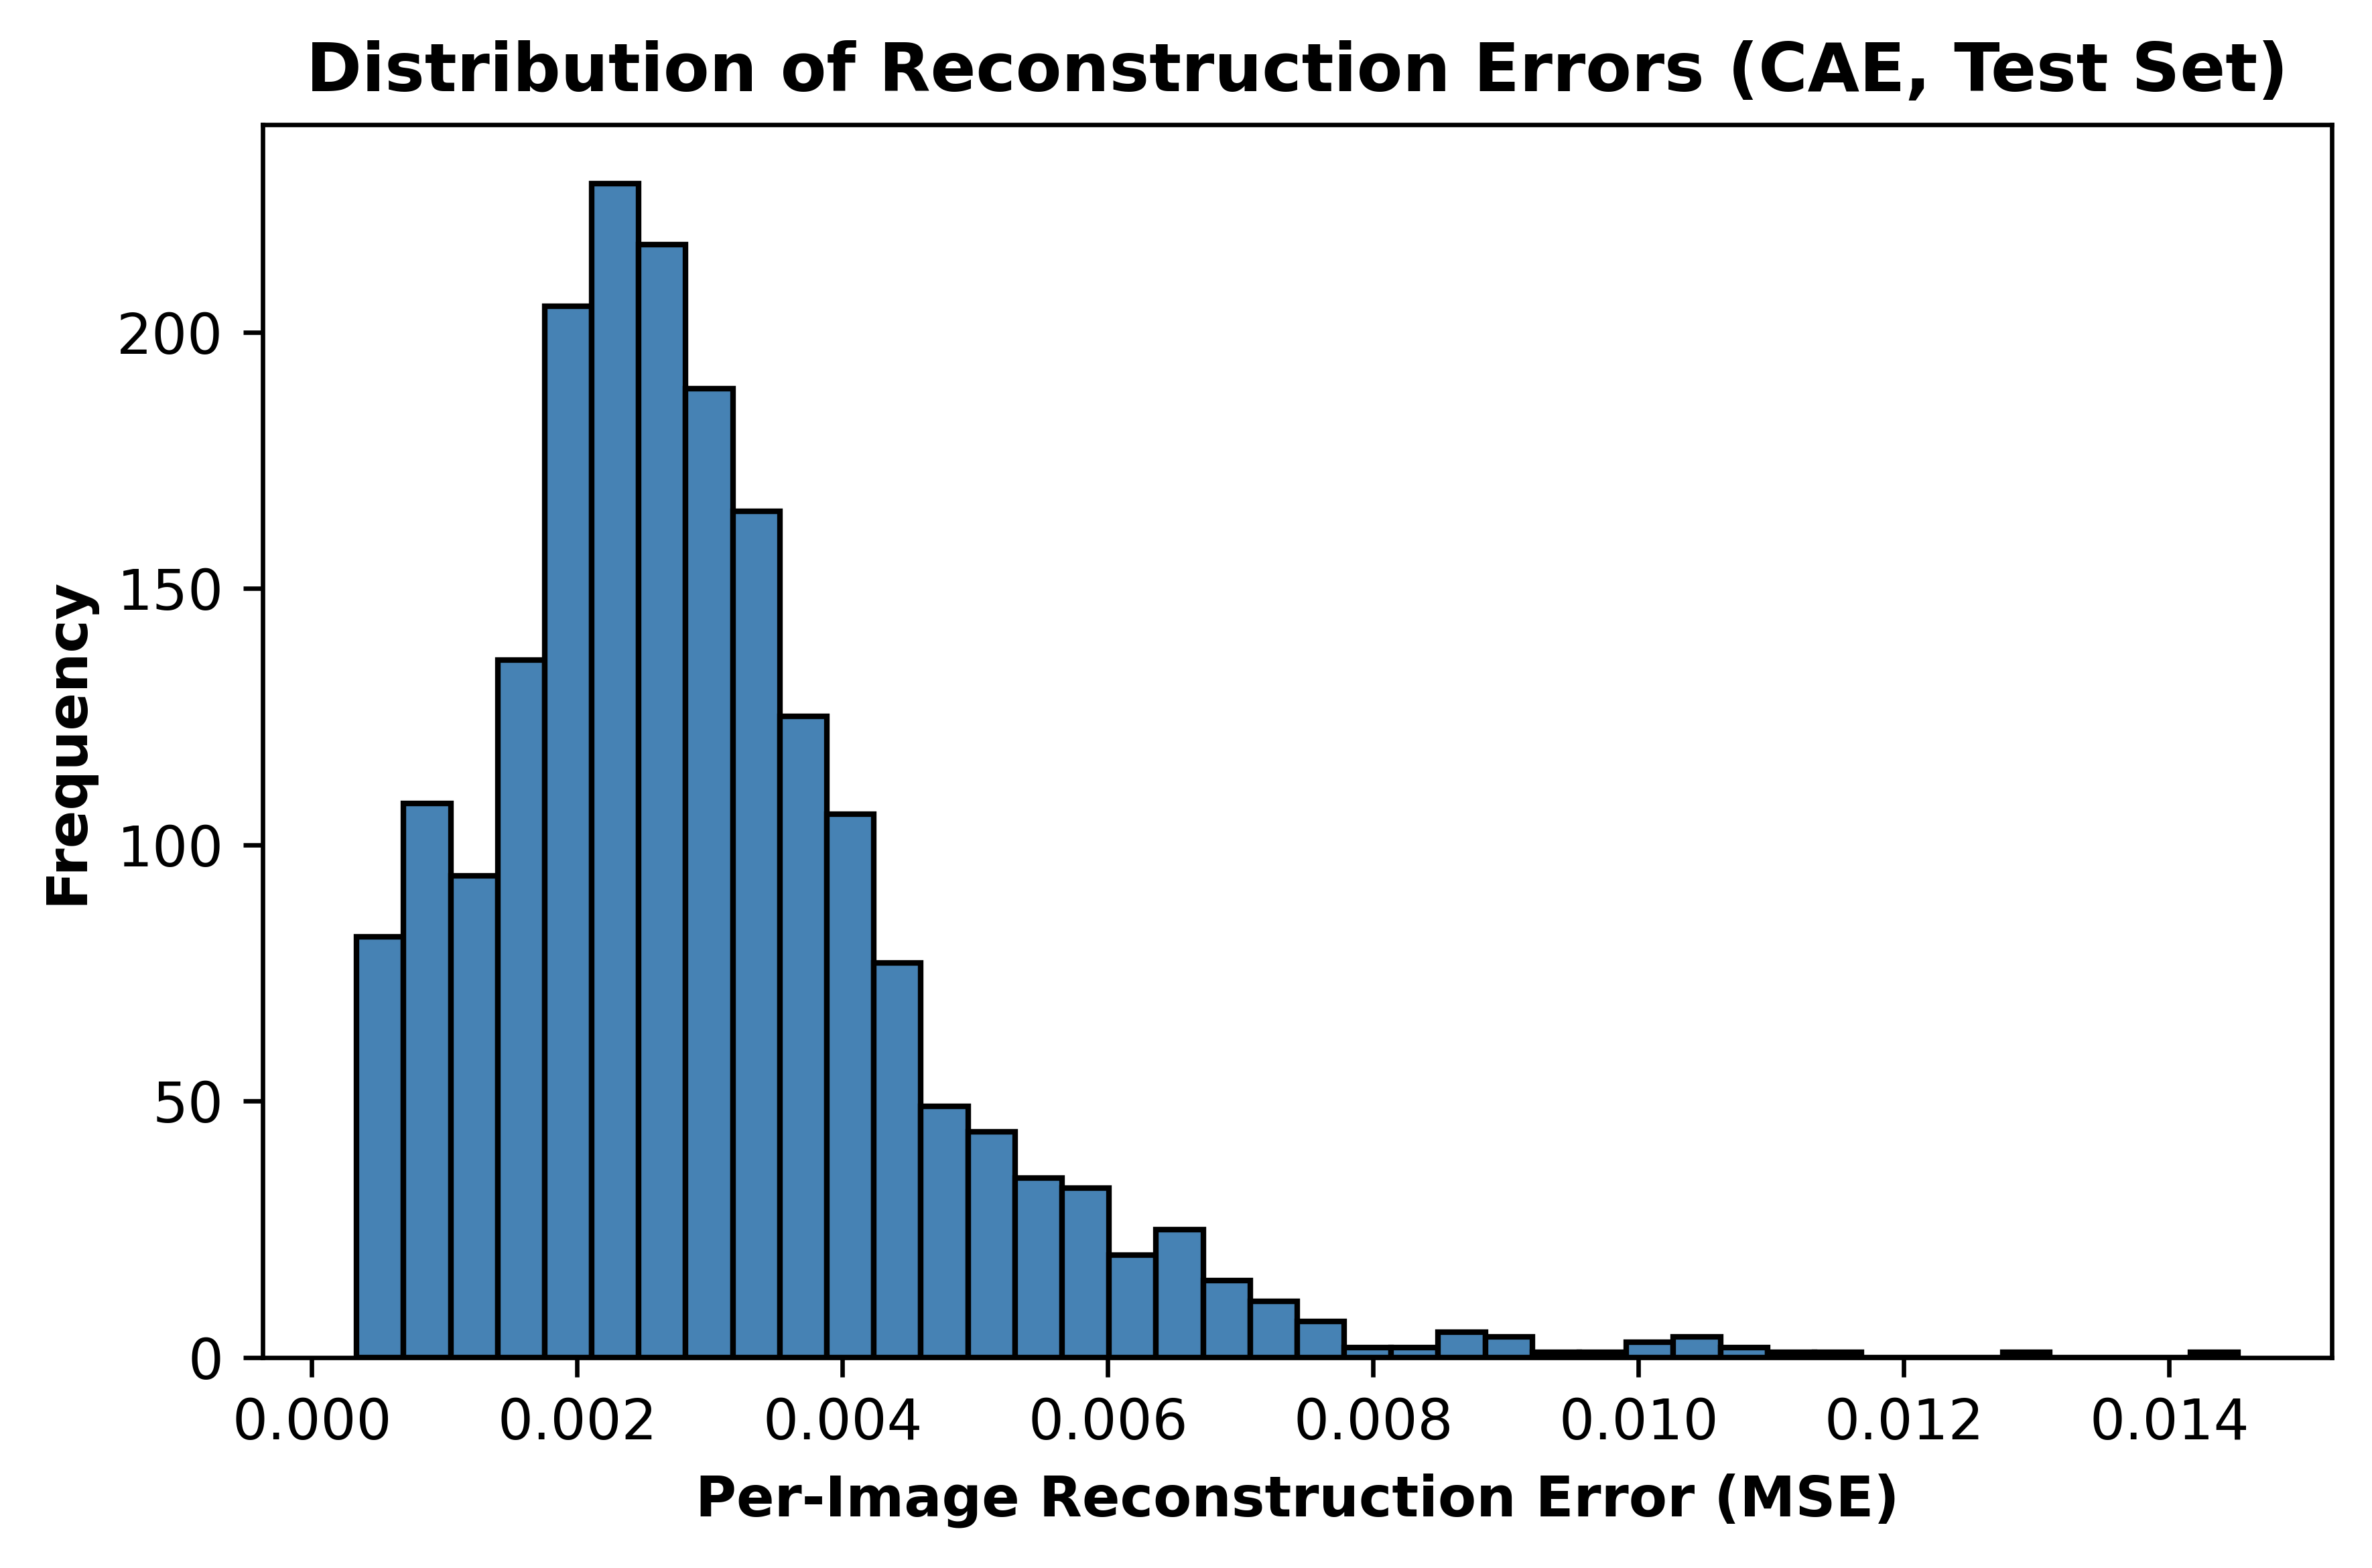

In [ ]:

per_image_error = np.mean((x_test_conv.reshape(len(x_test_conv), -1) -
                            cae_recon.reshape(len(cae_recon), -1)) ** 2, axis=1)

plt.figure(figsize=(6,4))
plt.hist(per_image_error, bins=40, color='steelblue', edgecolor='black')
plt.xlabel('Per-Image Reconstruction Error (MSE)', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Reconstruction Errors (CAE, Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('recon_error_distribution.png', dpi=600, bbox_inches='tight')
plt.show()


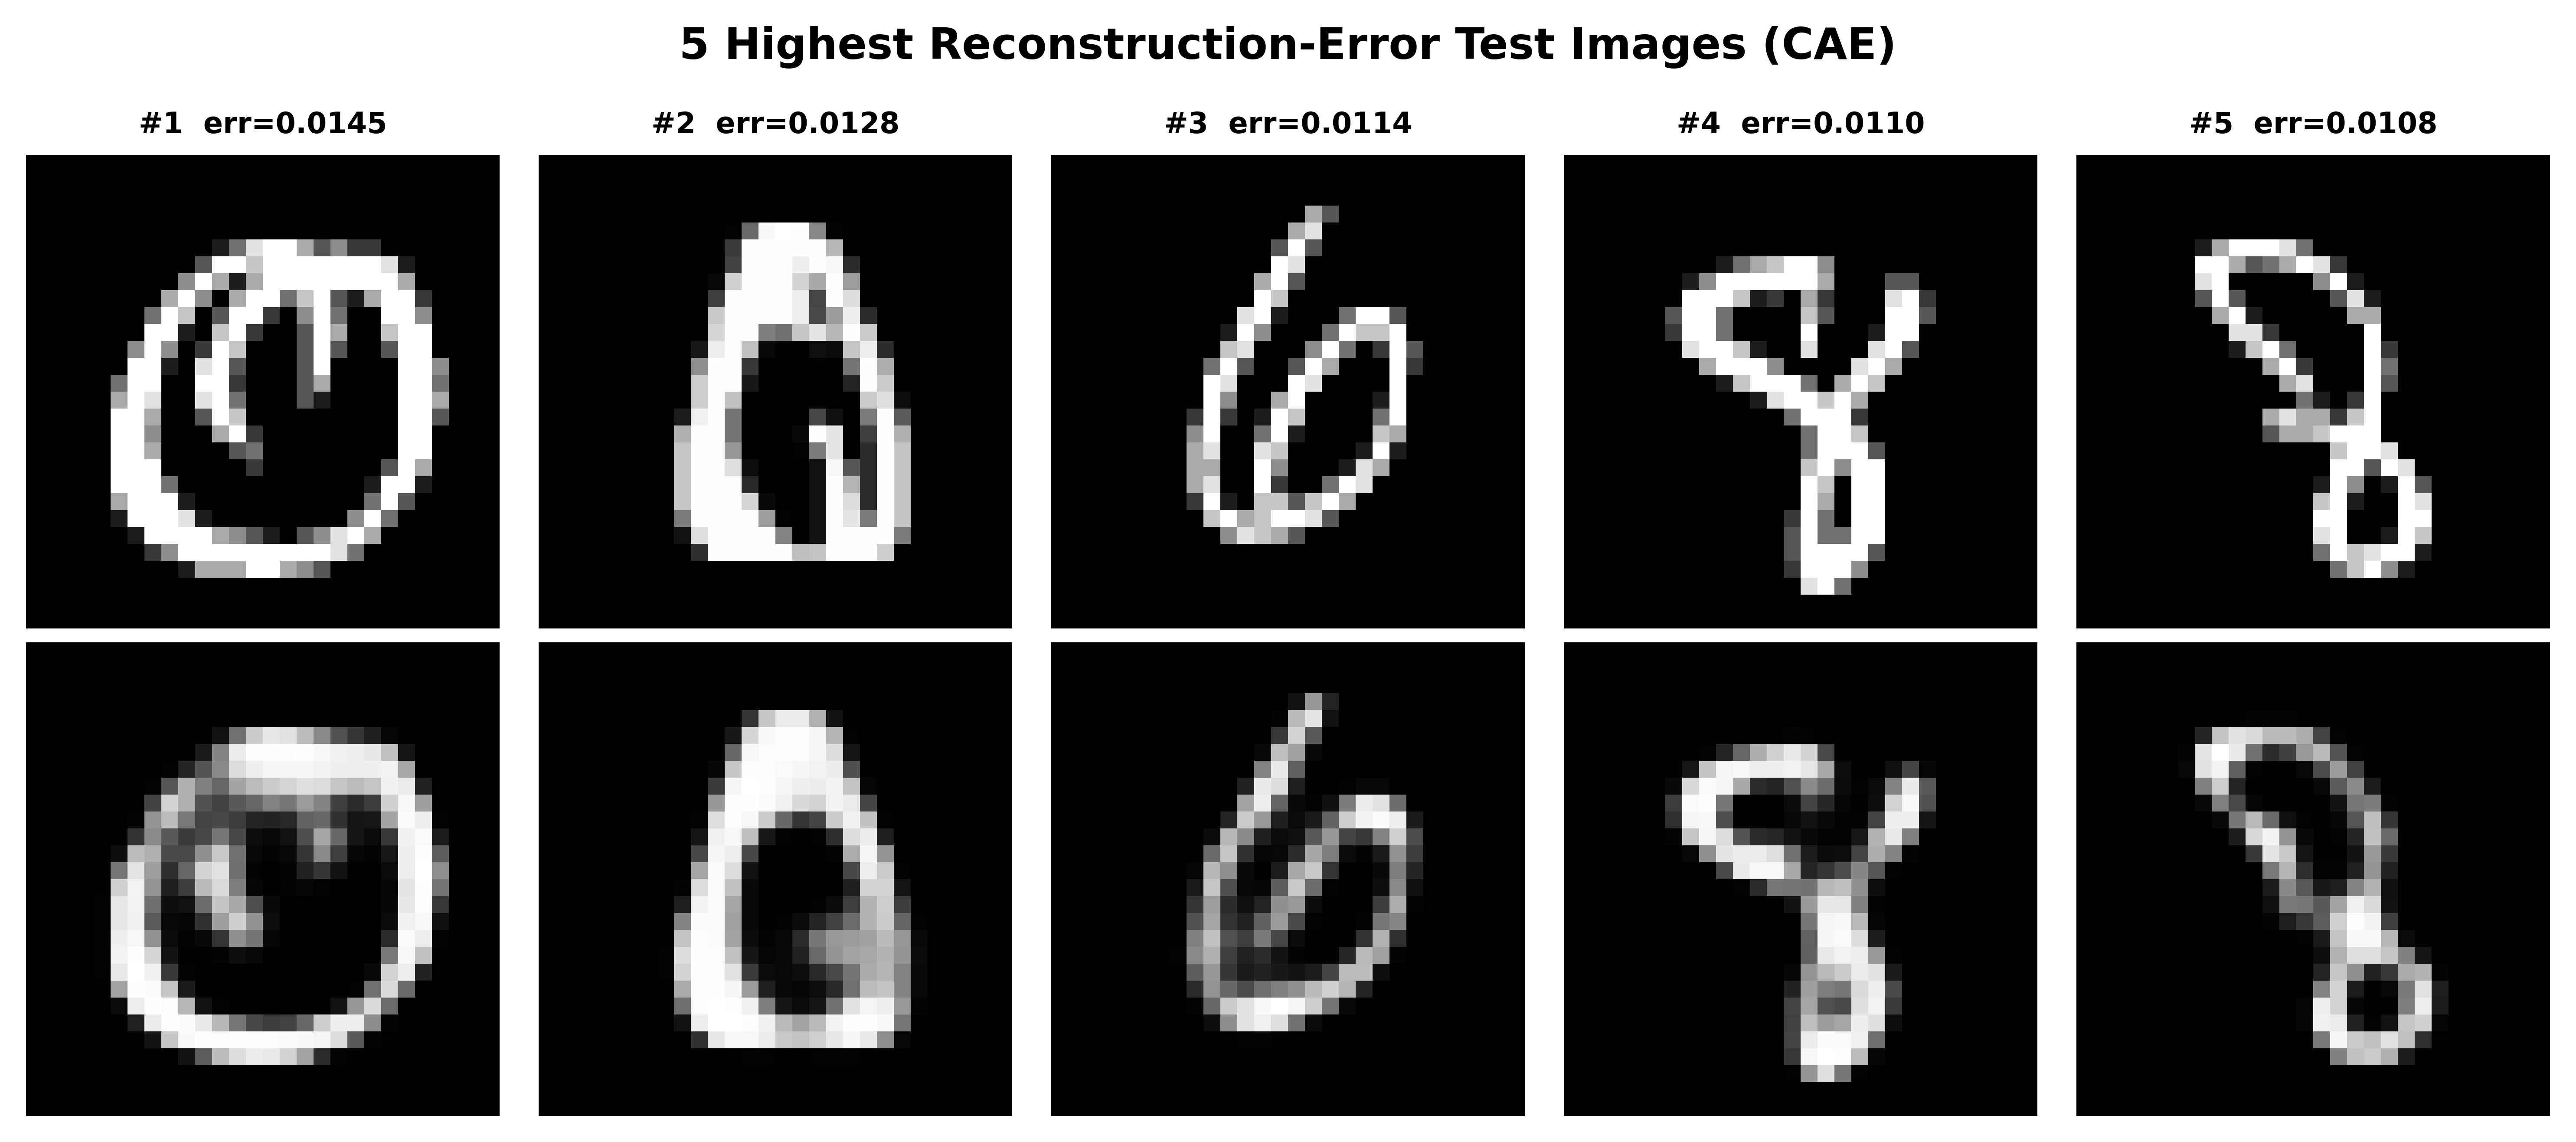

,Sample,Reconstruction Error (MSE)
0,1,0.014516
1,2,0.012787
2,3,0.011427
3,4,0.011013
4,5,0.010840


In [ ]:

worst_idx = np.argsort(per_image_error)[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, idx in enumerate(worst_idx):
    axes[0, i].imshow(x_test_conv[idx].reshape(28,28), cmap='gray')
    axes[0, i].set_title(f'#{i+1}  err={per_image_error[idx]:.4f}', fontsize=8, fontweight='bold')
    axes[0, i].axis('off')
    axes[1, i].imshow(cae_recon[idx].reshape(28,28), cmap='gray')
    axes[1, i].axis('off')
axes[0,0].set_ylabel('Original', fontweight='bold')
axes[1,0].set_ylabel('Reconstruction', fontweight='bold')
plt.suptitle('5 Highest Reconstruction-Error Test Images (CAE)', fontweight='bold')
plt.tight_layout()
plt.savefig('high_error_samples.png', dpi=600, bbox_inches='tight')
plt.show()

high_error_table = pd.DataFrame({
    'Sample': range(1, 6),
    'Reconstruction Error (MSE)': per_image_error[worst_idx]
})
high_error_table


In [ ]:

latent_dims = [2, 8, 16, 32]
latent_dim_results = []

for dz in latent_dims:
    model, _ = build_fc_autoencoder(latent_dim=dz)
    model.fit(x_train_flat, x_train_flat, epochs=12, batch_size=128, verbose=0)
    recon = model.predict(x_test_flat, verbose=0)
    mse, mae, s = compute_metrics(x_test_flat, recon)
    params = count_params(model)
    latent_dim_results.append((dz, mse, s, params))
    print(f"dz={dz:>2}  MSE={mse:.5f}  SSIM={s:.4f}  Params={params}")

latent_dim_table = pd.DataFrame(latent_dim_results, columns=['Latent Dimension', 'MSE', 'SSIM', 'Parameters'])
latent_dim_table


dz= 2  MSE=0.05625  SSIM=0.3047  Params=210130
dz= 8  MSE=0.03253  SSIM=0.6273  Params=210520
dz=16  MSE=0.02655  SSIM=0.6820  Params=211040
dz=32  MSE=0.02314  SSIM=0.7181  Params=212080


,Latent Dimension,MSE,SSIM,Parameters
0,2,0.056255,0.304693,210130
1,8,0.032527,0.627265,210520
2,16,0.026547,0.682034,211040
3,32,0.023135,0.718135,212080


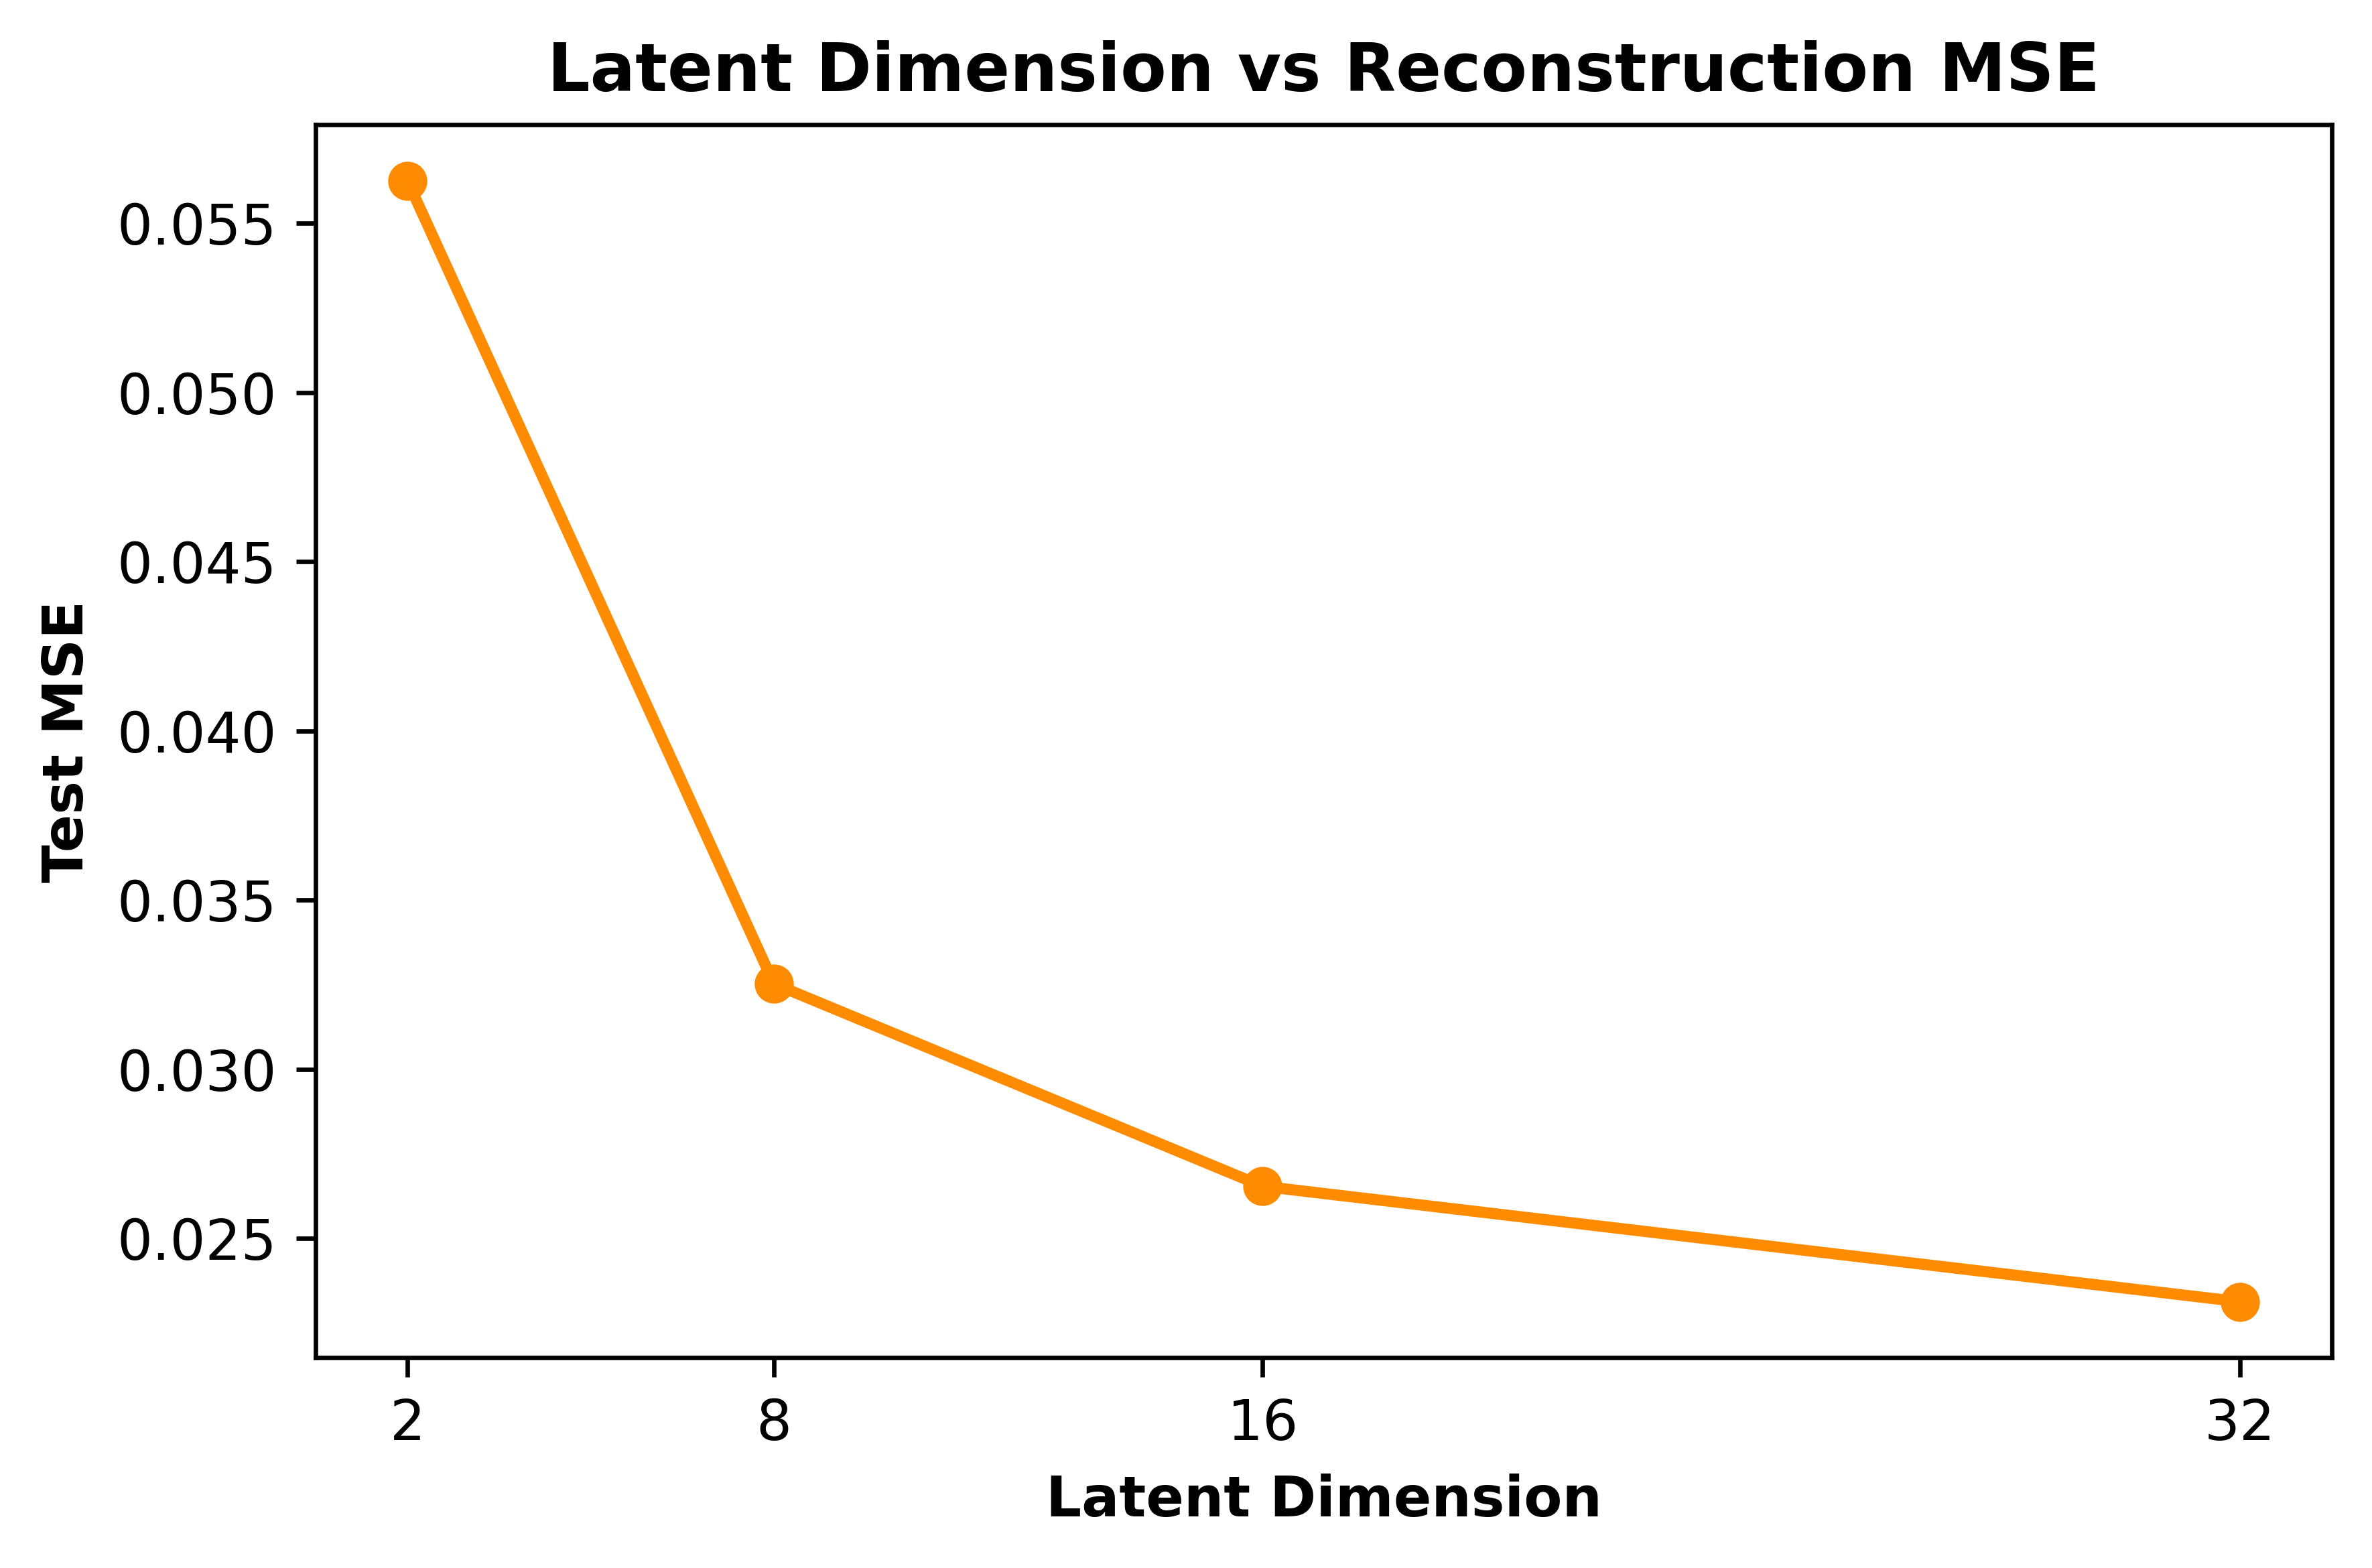

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(latent_dim_table['Latent Dimension'], latent_dim_table['MSE'], marker='o', linewidth=2, color='darkorange')
plt.xlabel('Latent Dimension', fontweight='bold')
plt.ylabel('Test MSE', fontweight='bold')
plt.title('Latent Dimension vs Reconstruction MSE', fontweight='bold')
plt.xticks(latent_dims)
plt.tight_layout()
plt.savefig('latent_dim_vs_mse.png', dpi=600, bbox_inches='tight')
plt.show()


In [ ]:

def build_conv_autoencoder_variable(latent_channels):
    inp = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(latent_channels, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, padding='same')(x)
    z = layers.Conv2D(latent_channels, 3, activation='relu', padding='same')(x)

    x = layers.UpSampling2D(2)(z)
    x = layers.Conv2D(latent_channels, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m

ex1_results = []
for lc in [4, 8, 16, 32]:
    m = build_conv_autoencoder_variable(lc)
    m.fit(x_train_conv, x_train_conv, epochs=8, batch_size=128, verbose=0)
    recon = m.predict(x_test_conv, verbose=0)
    mse, mae, s = compute_metrics(x_test_conv, recon)
    ex1_results.append((lc, mse, mae, s))

ex1_table = pd.DataFrame(ex1_results, columns=['Latent Channels', 'MSE', 'MAE', 'SSIM'])
ex1_table


,Latent Channels,MSE,MAE,SSIM
0,4,0.019347,0.053206,0.792876
1,8,0.010580,0.034231,0.893574
2,16,0.005868,0.023523,0.940982
3,32,0.004461,0.020037,0.954720


In [ ]:

# Reuses the noise levels/results already computed in Section 3 (gaussian_table, sp_table)
comparison_ex2 = pd.concat([
    gaussian_table.rename(columns={'Noise Level (sigma)': 'Noise Level'}).assign(Type='Gaussian'),
    sp_table.rename(columns={'Noise Level (p)': 'Noise Level'}).assign(Type='Salt-and-Pepper')
], ignore_index=True)
comparison_ex2


,Noise Level,MSE,MAE,SSIM,Type
0,0.10,0.004042,0.018699,0.955667,Gaussian
1,0.20,0.005047,0.022242,0.940823,Gaussian
2,0.30,0.007544,0.030127,0.873935,Gaussian
3,0.05,0.005245,0.021863,0.930027,Salt-and-Pepper
4,0.10,0.007285,0.027324,0.887436,Salt-and-Pepper
5,0.20,0.013567,0.041856,0.769977,Salt-and-Pepper


In [ ]:

def train_dae_at_sigma(sigma, epochs=10):
    m = build_denoising_cae()
    noisy_train = add_gaussian_noise(x_train_conv, sigma)
    m.fit(noisy_train, x_train_conv, epochs=epochs, batch_size=128, verbose=0)
    noisy_test = add_gaussian_noise(x_test_conv, sigma)
    recon = m.predict(noisy_test, verbose=0)
    return compute_metrics(x_test_conv, recon)

ex3_low = train_dae_at_sigma(0.1)
ex3_high = train_dae_at_sigma(0.3)

ex3_table = pd.DataFrame({
    'Training Noise Level': [0.1, 0.3],
    'MSE': [ex3_low[0], ex3_high[0]],
    'MAE': [ex3_low[1], ex3_high[1]],
    'SSIM': [ex3_low[2], ex3_high[2]],
})
ex3_table


,Training Noise Level,MSE,MAE,SSIM
0,0.1,0.004105,0.019418,0.955713
1,0.3,0.008128,0.029516,0.901971


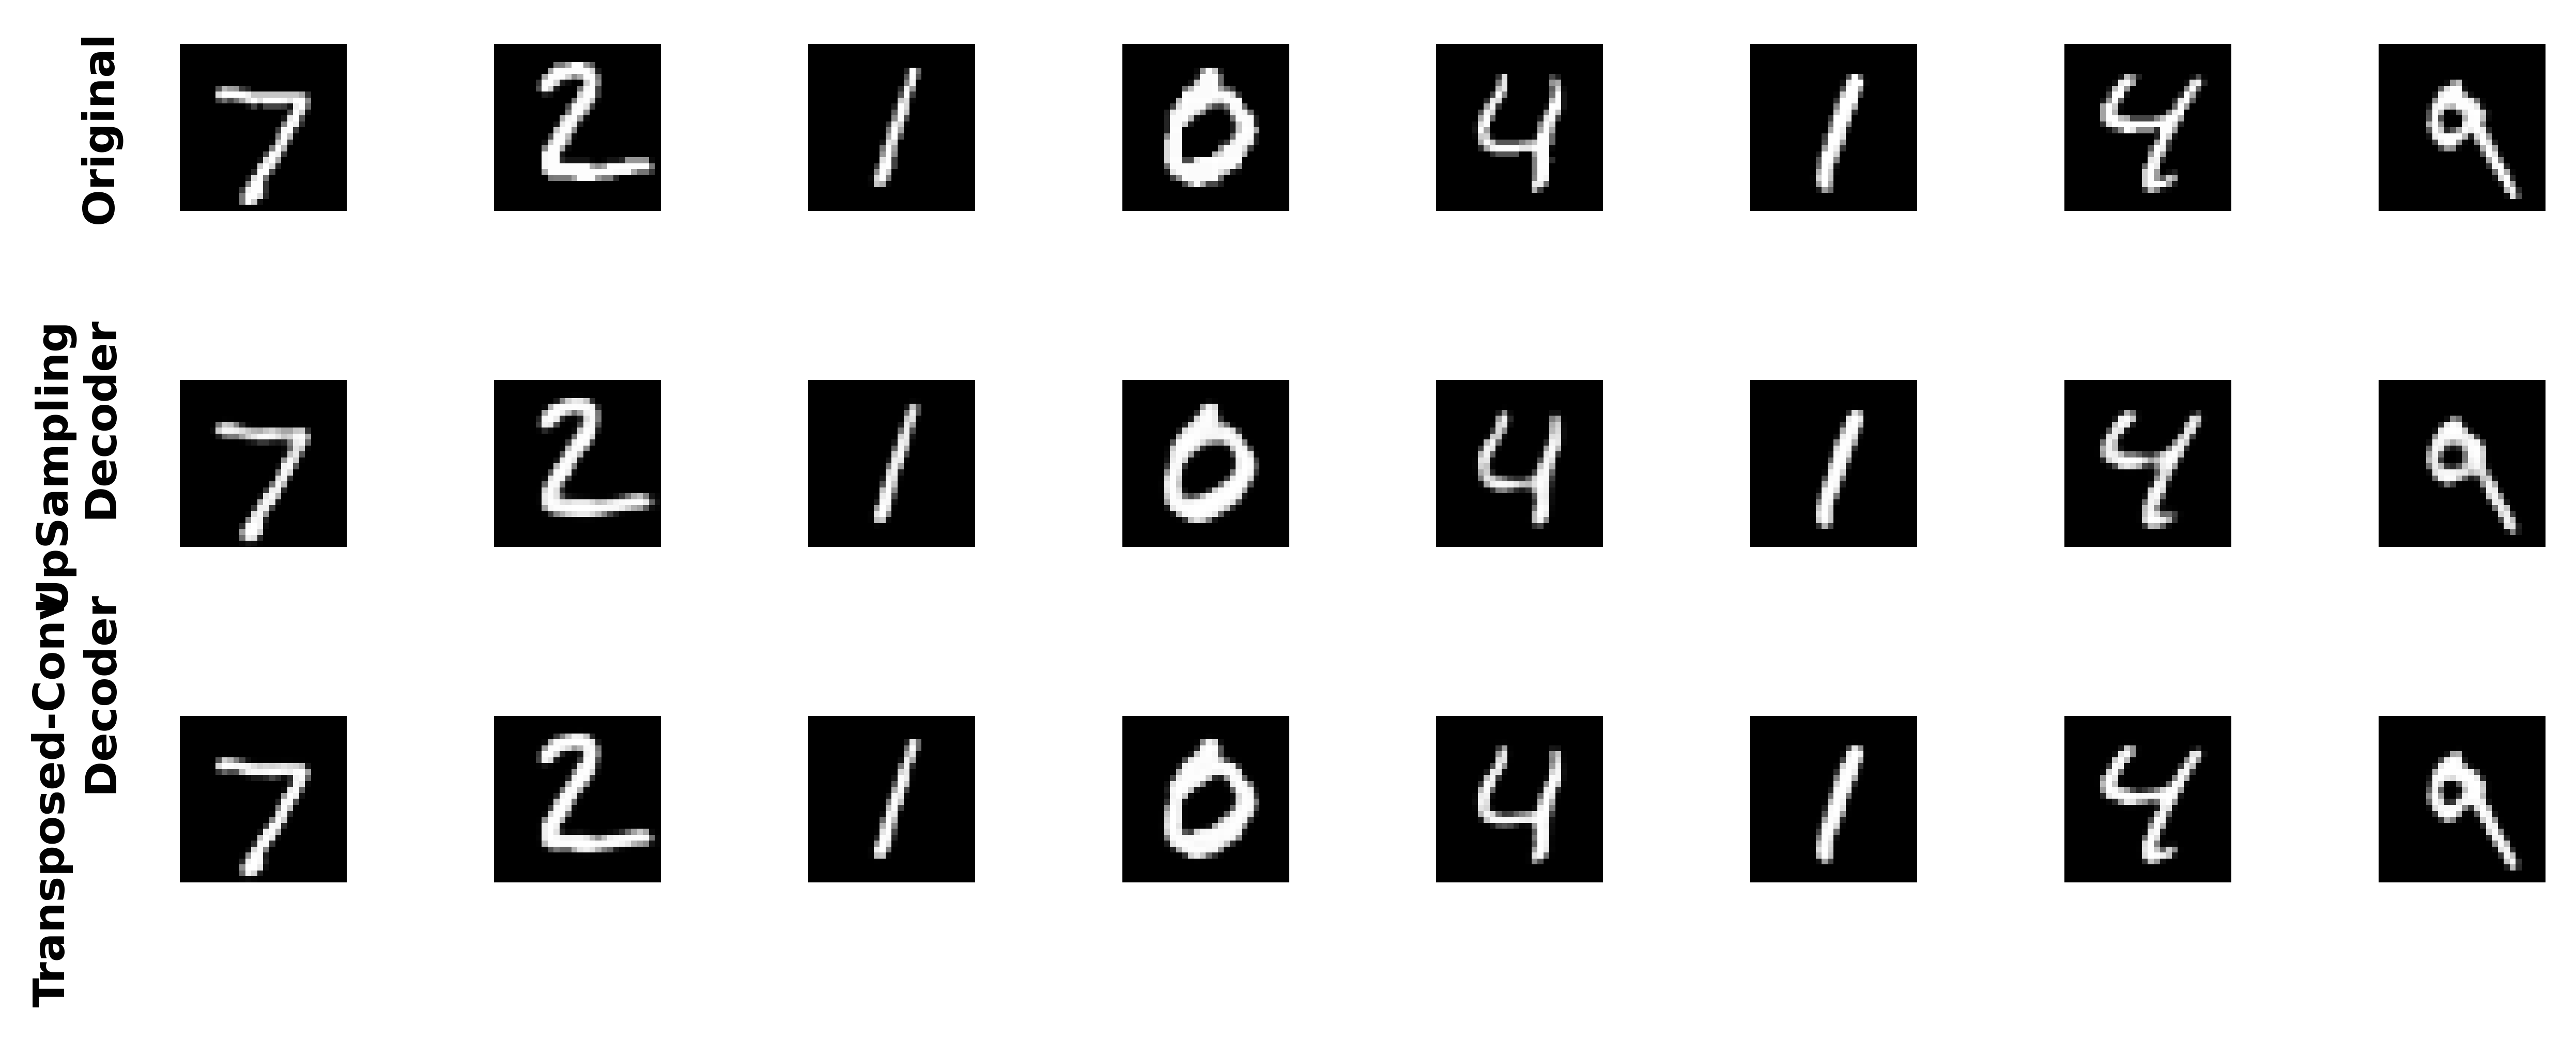

,Decoder,MSE,MAE,SSIM
0,UpSampling2D (Section 10 CAE),0.002974,0.016280,0.968968
1,Conv2DTranspose,0.000835,0.008888,0.990237


In [ ]:
def build_conv_autoencoder_transpose():
    inp = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inp)   # 14x14
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)     # 7x7
    z = x
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(z)  # 14x14
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)  # 28x28
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    m = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m

cae_transpose = build_conv_autoencoder_transpose()
cae_transpose.fit(x_train_conv, x_train_conv, epochs=12, batch_size=128, verbose=0)
transpose_recon = cae_transpose.predict(x_test_conv, verbose=0)
transpose_mse, transpose_mae, transpose_ssim = compute_metrics(x_test_conv, transpose_recon)

ex4_table = pd.DataFrame({
    'Decoder': ['UpSampling2D (Section 10 CAE)', 'Conv2DTranspose'],
    'MSE': [cae_mse, transpose_mse],
    'MAE': [cae_mae, transpose_mae],
    'SSIM': [cae_ssim, transpose_ssim],
})
show_grid([x_test_conv[:8], cae_recon[:8], transpose_recon[:8]],
          ['Original', 'UpSampling\nDecoder', 'Transposed-Conv\nDecoder'], n=8)
ex4_table

In [ ]:

def train_vae(latent_dim, epochs=15):
    enc = build_vae_encoder(latent_dim)
    dec = build_vae_decoder(latent_dim)
    m = VAE(enc, dec)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
    m.fit(x_train_conv, x_train_conv, epochs=epochs, batch_size=128, verbose=0)
    mu, log_var, z = enc.predict(x_test_conv, verbose=0)
    recon = dec.predict(z, verbose=0)
    mse, mae, s = compute_metrics(x_test_conv, recon)
    return m, enc, dec, mu, (mse, mae, s)

vae2_model, vae2_enc, vae2_dec, vae2_mu, vae2_metrics = train_vae(2)
vae8_model, vae8_enc, vae8_dec, vae8_mu, vae8_metrics = train_vae(8)

ex5_table = pd.DataFrame({
    'Latent Dimension': [2, 8],
    'MSE': [vae2_metrics[0], vae8_metrics[0]],
    'MAE': [vae2_metrics[1], vae8_metrics[1]],
    'SSIM': [vae2_metrics[2], vae8_metrics[2]],
})
ex5_table


,Latent Dimension,MSE,MAE,SSIM
0,2,0.046044,0.107249,0.454150
1,8,0.023984,0.061238,0.734471


In [ ]:

class BetaVAE(VAE):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(encoder, decoder, **kwargs)
        self.beta = beta

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(x)
            recon = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, recon), axis=(1, 2)))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1))
            total_loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {'loss': self.total_loss_tracker.result(), 'recon_loss': self.recon_loss_tracker.result(),
                'kl_loss': self.kl_loss_tracker.result()}

beta_results = []
for beta in [0.5, 1.0, 5.0]:
    enc = build_vae_encoder(2)
    dec = build_vae_decoder(2)
    bvae = BetaVAE(enc, dec, beta=beta)
    bvae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
    bvae.fit(x_train_conv, x_train_conv, epochs=12, batch_size=128, verbose=0)
    mu, log_var, z = enc.predict(x_test_conv, verbose=0)
    recon = dec.predict(z, verbose=0)
    mse, mae, s = compute_metrics(x_test_conv, recon)
    beta_results.append((beta, mse, s))

beta_table = pd.DataFrame(beta_results, columns=['Beta (KL weight)', 'MSE', 'SSIM'])
beta_table


,Beta (KL weight),MSE,SSIM
0,0.5,0.049738,0.425492
1,1.0,0.046994,0.437808
2,5.0,0.050113,0.417584


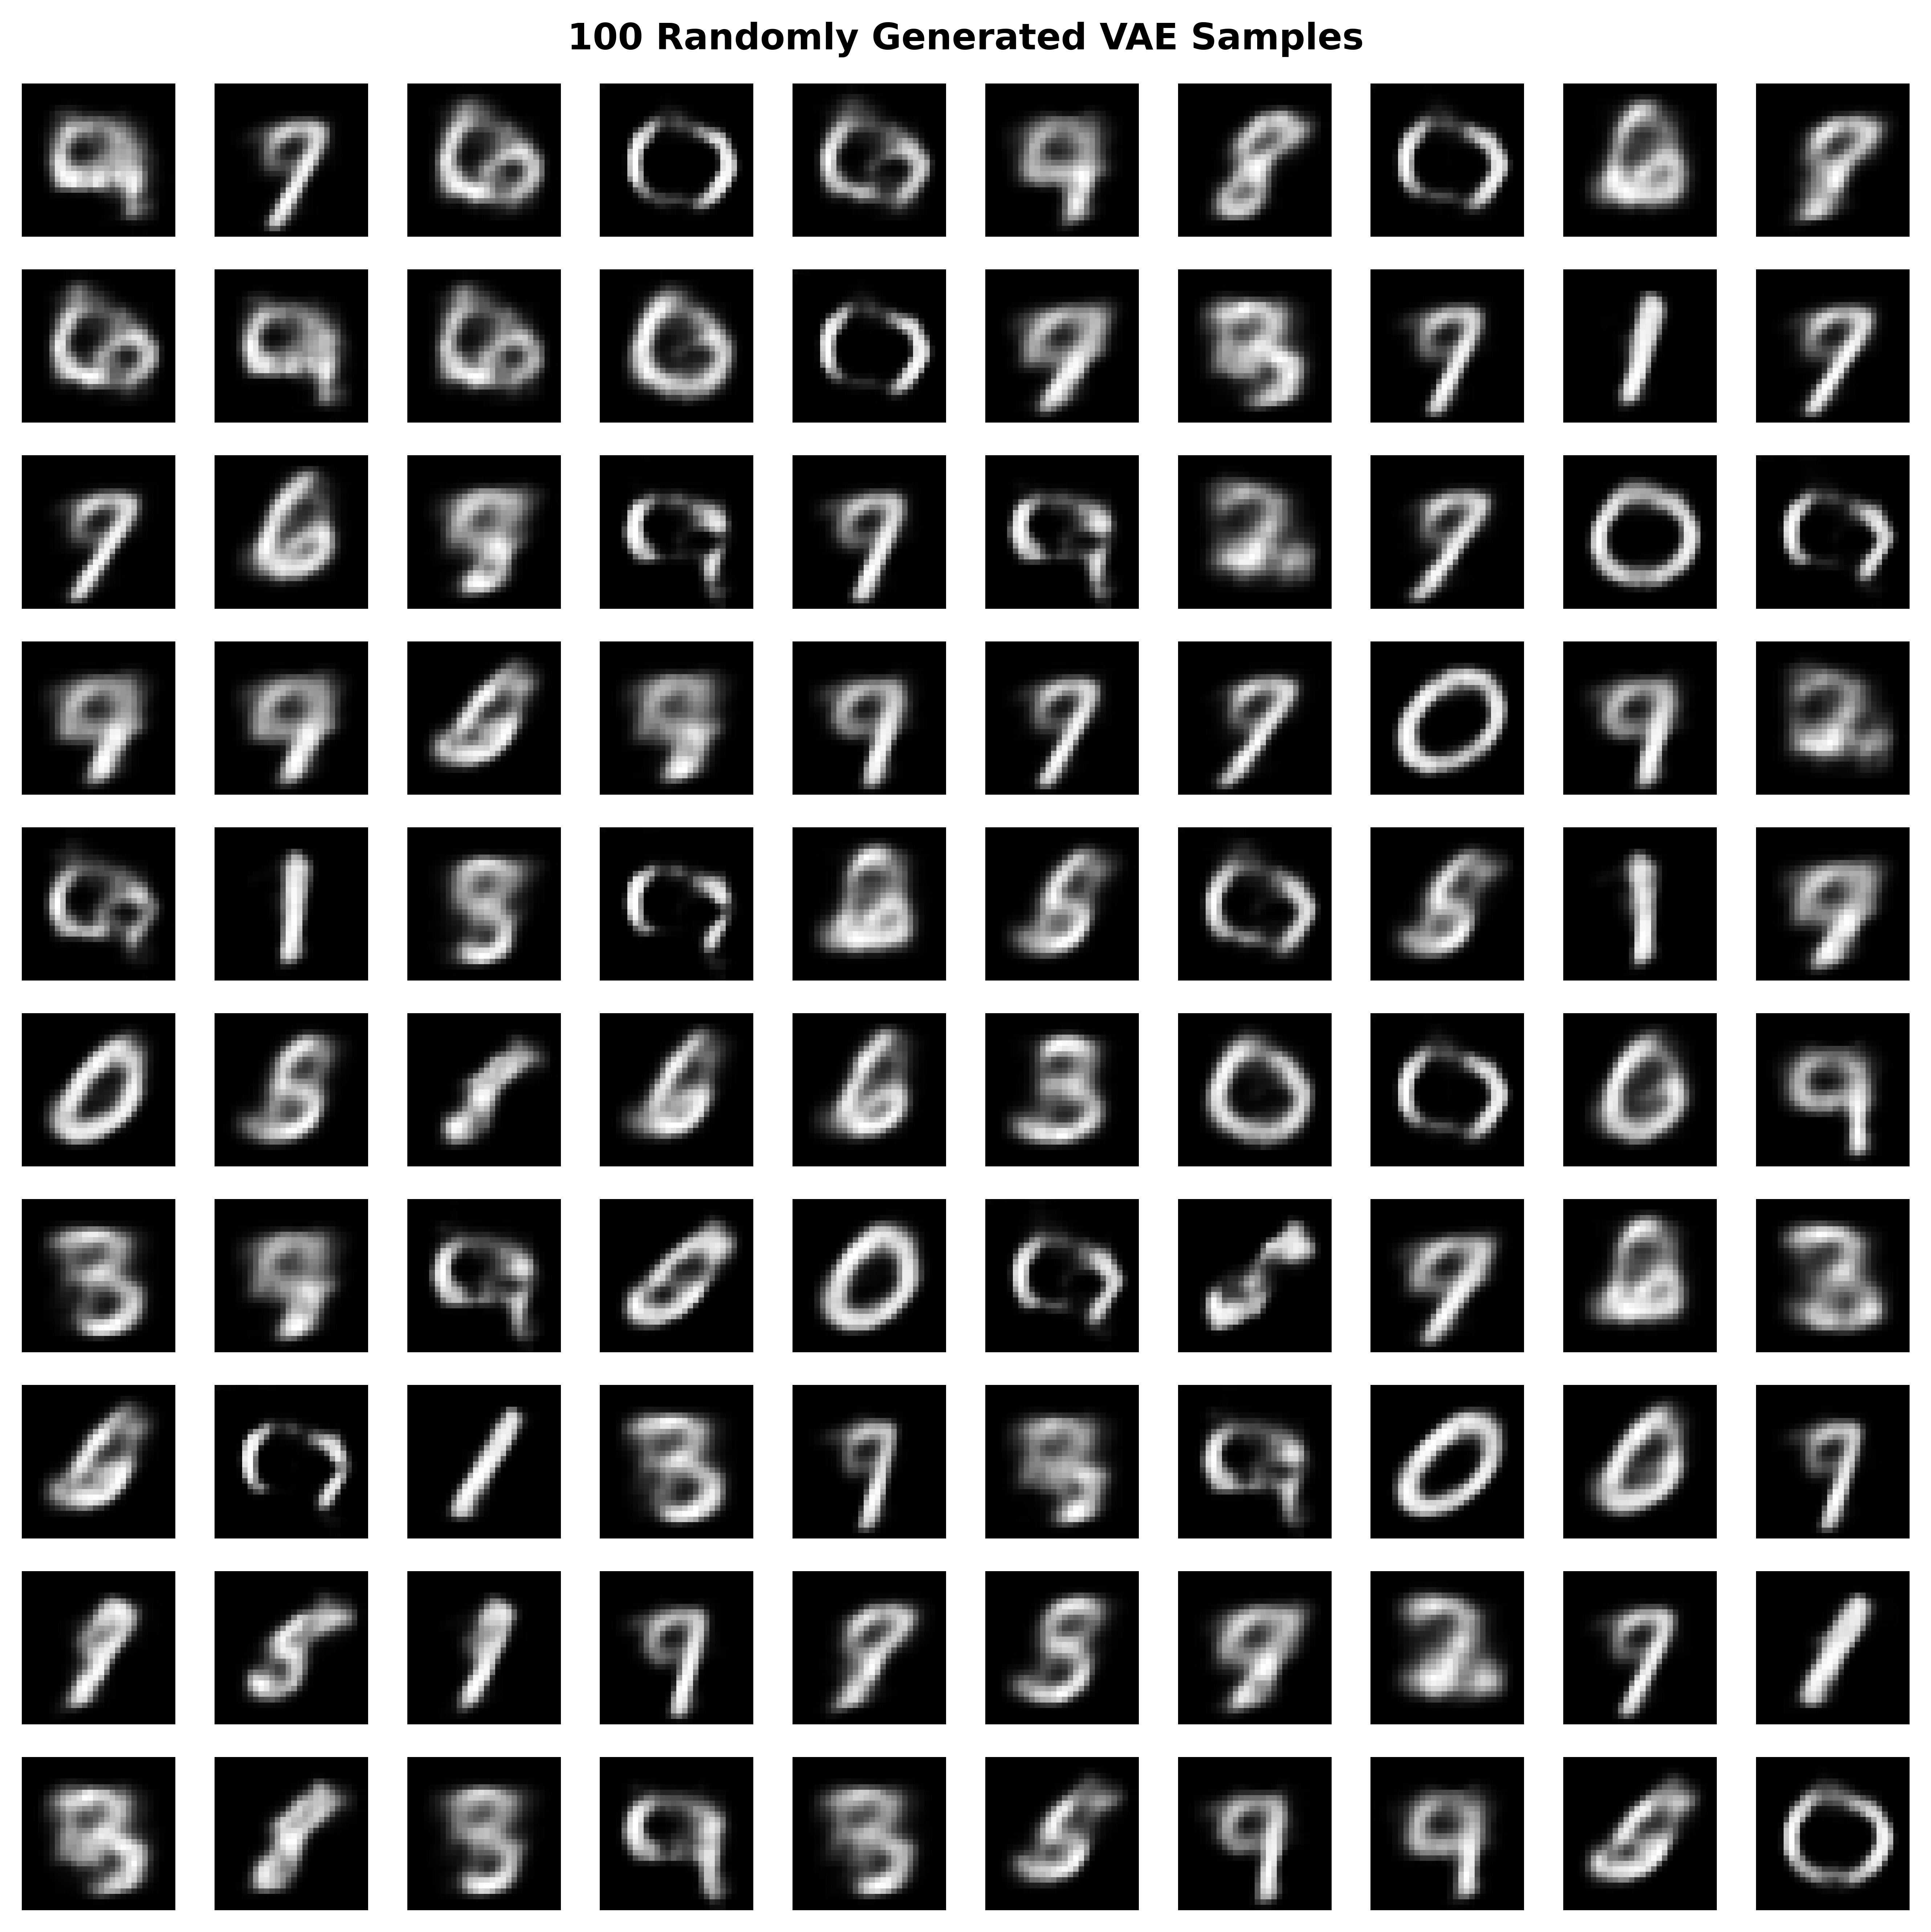

In [ ]:

n_large = 100
z_large = np.random.normal(0, 1, size=(n_large, VAE_LATENT_DIM)).astype('float32')
generated_large = vae_decoder.predict(z_large, verbose=0)

fig, axes = plt.subplots(10, 10, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_large[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('100 Randomly Generated VAE Samples', fontweight='bold')
plt.tight_layout()
plt.savefig('vae_generated_large_grid.png', dpi=600, bbox_inches='tight')
plt.show()


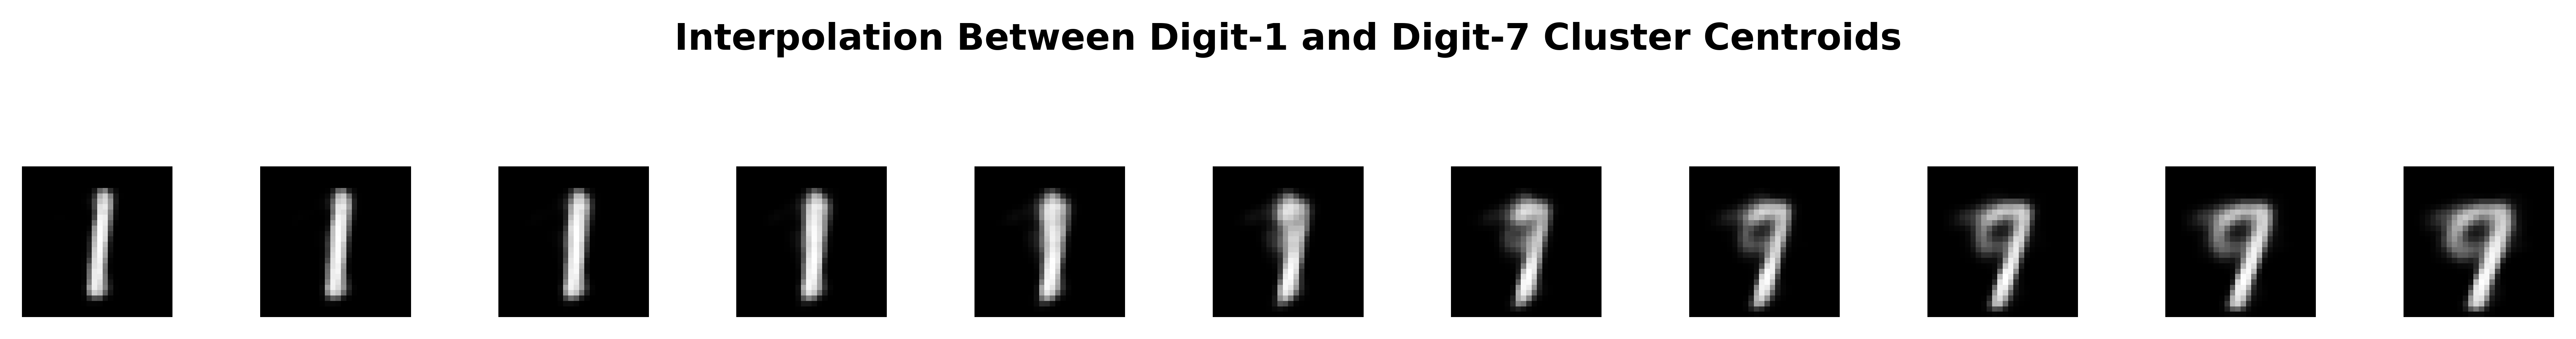

In [ ]:

digit_x, digit_y = 1, 7
centroid_x = vae_mu[y_test == digit_x].mean(axis=0)
centroid_y = vae_mu[y_test == digit_y].mean(axis=0)

alphas2 = np.arange(0, 1.01, 0.1)
z_path = np.array([(1 - a) * centroid_x + a * centroid_y for a in alphas2])
decoded_path = vae_decoder.predict(z_path, verbose=0)

fig, axes = plt.subplots(1, len(alphas2), figsize=(len(alphas2) * 1.1, 1.3))
for i, ax in enumerate(axes):
    ax.imshow(decoded_path[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle(f'Interpolation Between Digit-{digit_x} and Digit-{digit_y} Cluster Centroids', fontweight='bold', y=1.15)
plt.tight_layout()
plt.savefig('vae_region_interpolation.png', dpi=600, bbox_inches='tight')
plt.show()
